# 05 — Feature Engineering

**Input:** bảng `public.cleaned_city_temperature` được bàn giao từ `03_data_cleaning.ipynb`.

**Output chính:** bảng `public.city_temperature_features` trong PostgreSQL. Các file `data/processed/feature_engineered_data.csv.gz`, `data/processed/feature_metadata.json`, `data/processed/feature_statistics.csv.gz` và `data/sample/feature_sample.csv` là bản bàn giao bổ sung cho kiểm tra và demo.

Notebook giữ nguyên grain **một thành phố tại một tháng**. Mỗi dòng được định danh bằng khóa nghiệp vụ `observation_date + city_name + country_name + latitude + longitude`; biến mục tiêu là `city_average_temperature`.

Kịch bản được chọn là **dự báo một tháng kế tiếp**: tại thời điểm dự báo, mô hình được phép dùng thuộc tính tĩnh của địa điểm và dữ liệu các tháng trước, nhưng không được dùng phép đo của chính tháng đang dự báo.


## 1. Mục tiêu, vai trò và pipeline Feature Engineering

### 1.1. Mục tiêu của Notebook

Notebook 05 biến tập dữ liệu đã làm sạch thành một tập **đặc trưng (feature)** có căn cứ, không rò rỉ dữ liệu và sẵn sàng cho huấn luyện mô hình. Các công việc chính gồm:

1. Chuyển các quan sát định lượng của Notebook 04 thành ý tưởng đặc trưng cụ thể, mỗi đặc trưng đều có lý do xuất phát từ EDA.
2. Xây dựng bảy nhóm đặc trưng: thời gian, địa lý, tương tác, khí hậu theo vị trí, trễ/trượt, bối cảnh toàn cầu và chất lượng dữ liệu.
3. Đánh giá từng đặc trưng bằng tương quan tuyến tính, tương quan hạng, tỷ lệ phương sai giải thích và feature importance.
4. Kiểm tra và loại bỏ hai rủi ro đã được Notebook 04 chỉ ra: **rò rỉ dữ liệu (leakage)** và **đa cộng tuyến (multicollinearity)**.
5. Lựa chọn đặc trưng bằng bộ quy tắc định lượng công khai, thay vì giữ lại toàn bộ.
6. Lưu tập đặc trưng cùng file metadata ghi rõ danh sách, thứ tự và mốc thời gian train để Notebook 06 tái sử dụng chính xác.

### 1.2. Vai trò của Feature Engineering trong dự án

Notebook 04 cho thấy các biến thô trong bảng sạch **không phản ánh đúng bản chất khí hậu** của dữ liệu:

- `month` và `quarter` chỉ có tương quan tuyến tính `r ≈ 0.10` với nhiệt độ, dù biên độ mùa vụ lên tới **13.04 °C**. Nguyên nhân là quan hệ tháng–nhiệt độ có tính **tuần hoàn**: tháng 12 và tháng 1 liền kề về khí hậu nhưng cách xa nhau về mặt số học.
- `year` và `decade` chỉ có `r ≈ 0.048`, dù xu hướng ấm lên là thật ở mức **xấp xỉ +0,027 °C/năm**. Tín hiệu dài hạn này bị biên độ mùa vụ và biên độ vĩ độ (lớn hơn nhiều) che lấp.
- `latitude` là driver địa lý mạnh nhất (`r = -0.467`) nhưng vì có dấu, nó trộn lẫn hai thông tin khác nhau: khoảng cách tới xích đạo và bán cầu.

Feature Engineering là bước biểu diễn lại các thông tin đó dưới dạng mà mô hình học được: mã hóa tuần hoàn cho mùa vụ, biến trôi thời gian cho xu hướng, khoảng cách tuyệt đối tới xích đạo cho vĩ độ. Đây cũng là bước duy nhất trong pipeline chịu trách nhiệm **chặn rò rỉ dữ liệu** trước khi mô hình được huấn luyện.

### 1.3. Kiến trúc pipeline

```text
public.cleaned_city_temperature  (5.579.085 dòng × 32 cột)
   ↓ chỉ đọc 16 cột cần dùng từ PostgreSQL
Bảng làm việc theo grain City–month
   ↓ chia thời gian: feature-fit → validation → test
7 nhóm đặc trưng an toàn theo kịch bản dự báo một tháng kế tiếp
   ↓ đánh giá chỉ trên validation
Kiểm tra leakage + multicollinearity
   ↓ bộ quy tắc lựa chọn định lượng
Danh sách đặc trưng cuối cùng
   ↓
public.city_temperature_features + metadata/file kiểm tra
   ↓
Notebook 06 — Machine Learning
```

Các nguyên tắc thiết kế chính:

- **PostgreSQL là nguồn duy nhất.** Notebook dừng nếu thiếu `.env`, không kết nối được hoặc chưa có bảng sạch.
- **Test được khóa khỏi quá trình chọn feature.** Các metric và feature importance chỉ dùng validation 1984–1993; test 1994–2013 dành cho Notebook 06.
- **Target statistics chống self-target leakage.** Các dòng feature-fit dùng leave-one-out; validation/test chỉ dùng thống kê học từ giai đoạn kết thúc năm 1983.
- **Feature động chỉ nhìn quá khứ.** Lag nhiệt độ, chỉ số toàn cầu và uncertainty đều dùng tháng trước; không dùng phép đo của tháng đang dự báo.
- **Feature suy ra trực tiếp từ target không được xuất.** `temp_anomaly_vs_climatology` chỉ phục vụ insight ở Mục 8.


## 2. Chuẩn bị môi trường và cấu hình

### 2.1. Nạp các thư viện cần thiết

`pandas` và `numpy` phục vụ xây dựng đặc trưng; `matplotlib` và `seaborn` vẽ biểu đồ đánh giá; `SQLAlchemy` kết hợp `psycopg2` dùng để đọc/ghi PostgreSQL; `python-dotenv` nạp cấu hình từ `.env` mà không ghi mật khẩu vào notebook.

In [1]:
import gc
import json
import os
import shutil
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5.5)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore', category=FutureWarning)

print(f'pandas {pd.__version__} · numpy {np.__version__}')

pandas 3.0.5 · numpy 2.5.1


Notebook chỉ dùng các thư viện đã có trong `requirements.txt`. `scikit-learn` là **tùy chọn**: nếu môi trường chưa cài, Mục 6.3 sẽ tự chuyển sang phương án đánh giá thuần `pandas`/`numpy` và notebook vẫn chạy hết.

### 2.2. Xác định thư mục dự án và đầu ra

Notebook có thể được mở từ thư mục gốc, `notebooks_v1/` hoặc `notebooks_v2/`. Hàm dưới tìm project root dựa trên hai thư mục ổn định `data/` và `SQL/`, sau đó chuẩn bị các thư mục đầu ra.

In [2]:
def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc chứa cả data/ và SQL/."""
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'SQL').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root chứa data/ và SQL/.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
SAMPLE_DIR = PROJECT_ROOT / 'data' / 'sample'
REPORT_IMAGES_DIR = PROJECT_ROOT / 'reports' / 'images'
for directory in (PROCESSED_DIR, SAMPLE_DIR, REPORT_IMAGES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CLEANED_TABLE = 'cleaned_city_temperature'
FEATURE_TABLE = 'city_temperature_features'
METADATA_PATH = PROCESSED_DIR / 'feature_metadata.json'
FEATURE_STATS_PATH = PROCESSED_DIR / 'feature_statistics.csv.gz'
SAMPLE_PATH = SAMPLE_DIR / 'feature_sample.csv'

print('Project root   :', PROJECT_ROOT)
print('Input table    :', f'public.{CLEANED_TABLE}')
print('Processed dir  :', PROCESSED_DIR)
print('Report images  :', REPORT_IMAGES_DIR)


Project root   : E:\project1\Global-Surface-Temperature-Analysis
Input table    : public.cleaned_city_temperature
Processed dir  : E:\project1\Global-Surface-Temperature-Analysis\data\processed
Report images  : E:\project1\Global-Surface-Temperature-Analysis\reports\images


Đường dẫn in ra phải trỏ tới đúng project hiện tại. Notebook không đọc, ghi hoặc thay đổi bất kỳ file nào trong `data/raw/`.

### 2.3. Tham số cấu hình của notebook

Toàn bộ tham số được gom vào một cell để dễ kiểm soát:

- `FAST_MODE`: giới hạn số dòng của truy vấn PostgreSQL sau khi đã `ORDER BY` vị trí và thời gian, phù hợp để kiểm tra nhanh logic lag.
- `FEATURE_FIT_CUTOFF_YEAR = 1983`: giai đoạn dùng để học các thống kê target theo vị trí.
- `VALIDATION_START_YEAR = 1984` và `TRAIN_CUTOFF_YEAR = 1993`: validation 1984–1993 dùng để đánh giá/chọn feature; test 1994–2013 không tham gia quá trình này.
- `EVAL_SAMPLE_ROWS`: giới hạn kích thước mẫu lấy **từ validation**, không lấy từ toàn bộ dữ liệu.
- `OUTPUT_COMPRESSION`: điều khiển bản CSV kiểm tra; bảng PostgreSQL vẫn là đầu ra chính.


In [3]:
# --- Chế độ chạy ---------------------------------------------------------
FAST_MODE = False          # True: chạy thử nhanh trên một phần dữ liệu
FAST_MODE_ROWS = 400_000   # số dòng đầu theo thứ tự vị trí–thời gian

# --- Chia dữ liệu theo thời gian -----------------------------------------
FEATURE_FIT_CUTOFF_YEAR = 1983  # chỉ giai đoạn này được dùng để học target statistics
VALIDATION_START_YEAR = 1984    # validation: 1984–1993, dùng để chọn feature
TRAIN_CUTOFF_YEAR = 1993        # test: 1994–2013, tuyệt đối không dùng để chọn feature

# --- Đánh giá đặc trưng --------------------------------------------------
EVAL_SAMPLE_ROWS = 400_000
ETA_SQUARED_BINS = 20
RANDOM_SEED = 42

# --- Quy tắc lựa chọn đặc trưng (Mục 7) ---------------------------------
MIN_ETA_SQUARED = 0.005
MIN_ABS_PEARSON = 0.05
REDUNDANCY_THRESHOLD = 0.95

# --- Đầu ra --------------------------------------------------------------
OUTPUT_COMPRESSION = 'gzip'
SAMPLE_ROWS = 50_000
TARGET_COLUMN = 'city_average_temperature'

rng = np.random.default_rng(RANDOM_SEED)
OUTPUT_PATH = PROCESSED_DIR / (
    'feature_engineered_data.csv.gz' if OUTPUT_COMPRESSION == 'gzip'
    else 'feature_engineered_data.csv'
)

if not FEATURE_FIT_CUTOFF_YEAR < VALIDATION_START_YEAR <= TRAIN_CUTOFF_YEAR:
    raise ValueError('Các mốc fit/validation/train không đúng thứ tự thời gian.')

print(f'FAST_MODE                  : {FAST_MODE}')
print(f'FEATURE_FIT_CUTOFF_YEAR    : {FEATURE_FIT_CUTOFF_YEAR}')
print(f'VALIDATION_START_YEAR      : {VALIDATION_START_YEAR}')
print(f'TRAIN_CUTOFF_YEAR          : {TRAIN_CUTOFF_YEAR}')
print(f'EVAL_SAMPLE_ROWS           : {EVAL_SAMPLE_ROWS:,}')
print(f'Target                     : {TARGET_COLUMN}')
print(f'Output                     : {OUTPUT_PATH.name}')


FAST_MODE                  : False
FEATURE_FIT_CUTOFF_YEAR    : 1983
VALIDATION_START_YEAR      : 1984
TRAIN_CUTOFF_YEAR          : 1993
EVAL_SAMPLE_ROWS           : 400,000
Target                     : city_average_temperature
Output                     : feature_engineered_data.csv.gz


Nếu `FAST_MODE = True`, mọi số liệu in ra sau đó chỉ mang tính kiểm tra logic và **không được dùng cho báo cáo**. Kết quả chính thức phải chạy với `FAST_MODE = False`.

### 2.4. Kết nối PostgreSQL bắt buộc


Notebook 05 chỉ đọc dữ liệu từ `public.cleaned_city_temperature` trong PostgreSQL để tuân thủ pipeline đã thống nhất từ Notebook 02–04. Không có nhánh fallback CSV: nếu database không khả dụng, notebook dừng và báo rõ lỗi để tránh vô tình dùng một bản dữ liệu khác.

Tạo file `.env` ở project root từ `.env.example`:

```text
DB_HOST=localhost
DB_PORT=5432
DB_NAME=climate_db
DB_USER=postgres
DB_PASSWORD=<mật khẩu PostgreSQL trên máy đang chạy>
```


In [4]:
ENV_PATH = PROJECT_ROOT / '.env'
if not ENV_PATH.is_file():
    raise FileNotFoundError(
        f'Không tìm thấy {ENV_PATH}. Notebook 05 chỉ đọc dữ liệu từ PostgreSQL.'
    )

from dotenv import load_dotenv
from sqlalchemy import URL, create_engine, text

load_dotenv(ENV_PATH, override=False)
required_env = ('DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD')
missing_env = [name for name in required_env if not os.getenv(name)]
if missing_env:
    raise ValueError(f'.env thiếu các biến: {missing_env}')

DB_ENGINE = create_engine(
    URL.create(
        drivername='postgresql+psycopg2',
        username=os.environ['DB_USER'],
        password=os.environ['DB_PASSWORD'],
        host=os.environ['DB_HOST'],
        port=int(os.environ['DB_PORT']),
        database=os.environ['DB_NAME'],
    ),
    pool_pre_ping=True,
    connect_args={'connect_timeout': 10},
)

check_sql = text(
    'SELECT current_database() AS database_name, '
    f"to_regclass('public.{CLEANED_TABLE}') IS NOT NULL AS source_table_exists"
)
with DB_ENGINE.connect() as connection:
    db_check = pd.read_sql_query(check_sql, connection)

display(db_check)
if not bool(db_check.loc[0, 'source_table_exists']):
    raise RuntimeError(
        f'Không tìm thấy public.{CLEANED_TABLE}. Hãy hoàn thành Notebook 03 trước.'
    )

DB_AVAILABLE = True
DATA_SOURCE = f'POSTGRESQL · public.{CLEANED_TABLE}'
print('PostgreSQL:', f"Đã kết nối {db_check.loc[0, 'database_name']}.public.{CLEANED_TABLE}")


,database_name,source_table_exists
0,climate_db,True


PostgreSQL: Đã kết nối climate_db.public.cleaned_city_temperature


Cell kết nối chỉ thực hiện truy vấn kiểm tra database và sự tồn tại của bảng nguồn; mật khẩu không được hiển thị. Notebook chỉ tiếp tục khi kết nối thành công và `public.cleaned_city_temperature` tồn tại.


## 3. Đọc dữ liệu đã làm sạch

### 3.1. Xác nhận data contract từ Notebook 03

Theo Notebook 03, bảng sạch phải có **5.579.085 dòng**, **32 cột**, **50 quốc gia**, thời gian từ `1863-01-01` đến `2013-09-01` và không còn dòng nào thiếu biến mục tiêu. Các hằng số dưới đây được dùng để đối chiếu sau khi nạp dữ liệu.

In [5]:
EXPECTED_CLEAN_ROWS = 5_579_085
EXPECTED_COUNTRIES = 50
EXPECTED_MIN_DATE = pd.Timestamp('1863-01-01')
EXPECTED_MAX_DATE = pd.Timestamp('2013-09-01')

BUSINESS_KEY_COLUMNS = [
    'observation_date', 'city_name', 'country_name', 'latitude', 'longitude',
]
LOCATION_KEY_COLUMNS = ['city_name', 'country_name', 'latitude', 'longitude']

print(f'Kỳ vọng {EXPECTED_CLEAN_ROWS:,} dòng · {EXPECTED_COUNTRIES} quốc gia · '
      f'{EXPECTED_MIN_DATE.date()} → {EXPECTED_MAX_DATE.date()}')

Kỳ vọng 5,579,085 dòng · 50 quốc gia · 1863-01-01 → 2013-09-01


### 3.2. Chọn cột cần dùng và kiểu dữ liệu tối ưu

Bảng sạch có 32 cột nhưng Notebook 05 chỉ đọc **16 cột** để giảm thời gian truyền và bộ nhớ.

Các cột nhiệt độ cùng tháng chỉ được đọc khi cần chứng minh hoặc tạo phiên bản lag an toàn:

- `major_city_average_temperature` và `country_average_temperature` được dùng ở Mục 6.5 để chứng minh rò rỉ rồi loại.
- `land_average_temperature` chỉ là nguồn để tạo `land_temperature_lag_1`; bản cùng tháng không được đưa vào candidate feature.
- `city_average_temperature_uncertainty` chỉ là nguồn để tạo `city_uncertainty_lag_1`; uncertainty cùng tháng không được dùng dự báo.

Các biến `land_max_temperature`, `land_min_temperature` và `land_and_ocean_average_temperature` không cần đọc vì đều là bối cảnh cùng tháng, không phù hợp kịch bản dự báo một tháng kế tiếp.


In [6]:
CALENDAR_COLUMNS = ['year', 'month', 'quarter', 'decade']
TEMPERATURE_COLUMNS = [
    TARGET_COLUMN,                              # biến mục tiêu
    'city_average_temperature_uncertainty',     # nguồn tạo uncertainty lag 1
    'land_average_temperature',                 # nguồn tạo chỉ số toàn cầu lag 1
    'country_average_temperature',              # đọc để chứng minh rủi ro ở Mục 6.5
    'major_city_average_temperature',           # đọc để chứng minh rò rỉ ở Mục 6.5
]
FLAG_COLUMNS = ['is_major_city', 'city_temperature_iqr_outlier']

USED_COLUMNS = BUSINESS_KEY_COLUMNS + CALENDAR_COLUMNS + TEMPERATURE_COLUMNS + FLAG_COLUMNS

# Kiểu dữ liệu nhỏ nhất còn biểu diễn đúng giá trị (xem CHECK constraint của Notebook 03).
READ_DTYPES = {
    'year': 'int16', 'month': 'int8', 'quarter': 'int8', 'decade': 'int16',
    'city_name': 'category', 'country_name': 'category',
    'latitude': 'float32', 'longitude': 'float32',
    **{column: 'float32' for column in TEMPERATURE_COLUMNS},
}

print(f'Đọc {len(USED_COLUMNS)}/32 cột:')
for index, column in enumerate(USED_COLUMNS, start=1):
    print(f'  {index:2d}. {column}')

Đọc 16/32 cột:
   1. observation_date
   2. city_name
   3. country_name
   4. latitude
   5. longitude
   6. year
   7. month
   8. quarter
   9. decade
  10. city_average_temperature
  11. city_average_temperature_uncertainty
  12. land_average_temperature
  13. country_average_temperature
  14. major_city_average_temperature
  15. is_major_city
  16. city_temperature_iqr_outlier


`city_name` và `country_name` dùng `category` vì chỉ có 3.070 và 50 giá trị duy nhất trên hơn 5,5 triệu dòng — hạ từ chuỗi Python xuống mã số nguyên tiết kiệm phần lớn bộ nhớ của hai cột này. Các cột nhiệt độ dùng `float32` thay vì `float64`: dữ liệu gốc chỉ có 3 chữ số thập phân nên không mất thông tin, mà giảm một nửa bộ nhớ.

### 3.3. Nạp dữ liệu theo từng chunk

Dữ liệu được truy vấn từ PostgreSQL theo các chunk 500.000 dòng để giảm bộ nhớ đỉnh. Truy vấn có `ORDER BY country_name, city_name, latitude, longitude, observation_date`, giúp chuỗi của từng vị trí luôn đúng thứ tự trước khi tạo lag.


In [7]:
CHUNK_SIZE = 500_000


def compact_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
    """Chuẩn hóa kiểu dữ liệu của một chunk trước khi ghép DataFrame lớn."""
    chunk['observation_date'] = pd.to_datetime(
        chunk['observation_date'], errors='raise'
    )
    for column, dtype in READ_DTYPES.items():
        if column in chunk.columns and chunk[column].dtype.name != dtype:
            chunk[column] = chunk[column].astype(dtype)
    for column in FLAG_COLUMNS:
        if chunk[column].dtype != bool:
            chunk[column] = chunk[column].astype('bool')
    return chunk


limit_clause = f' LIMIT {FAST_MODE_ROWS}' if FAST_MODE else ''
query = text(
    f"SELECT {', '.join(USED_COLUMNS)} FROM public.{CLEANED_TABLE} "
    'ORDER BY country_name, city_name, latitude, longitude, observation_date'
    f'{limit_clause}'
)

parts = []
with DB_ENGINE.connect() as connection:
    for chunk in pd.read_sql_query(query, connection, chunksize=CHUNK_SIZE):
        parts.append(compact_chunk(chunk))

if not parts:
    raise RuntimeError(f'public.{CLEANED_TABLE} không có dữ liệu.')

feature_df = pd.concat(parts, ignore_index=True)[USED_COLUMNS]

# LIMIT có thể cắt dở chuỗi của vị trí cuối. Loại vị trí đó trước mọi phép
# chia thời gian để DataFrame và các mask luôn cùng chỉ mục.
if FAST_MODE:
    last_location = feature_df.iloc[-1][LOCATION_KEY_COLUMNS]
    last_location_mask = pd.Series(True, index=feature_df.index)
    for column in LOCATION_KEY_COLUMNS:
        last_location_mask &= feature_df[column].eq(last_location[column])
    if (~last_location_mask).any():
        feature_df = feature_df.loc[~last_location_mask].reset_index(drop=True)

print(f'Nguồn dữ liệu : {DATA_SOURCE}')
print(f'Đã nạp        : {len(feature_df):,} dòng × {feature_df.shape[1]} cột')


Nguồn dữ liệu : POSTGRESQL · public.cleaned_city_temperature
Đã nạp        : 5,579,085 dòng × 16 cột


Dòng `Nguồn dữ liệu` phải luôn là `POSTGRESQL · public.cleaned_city_temperature`. Số cột đọc vào phải bằng 16; nếu kết nối hoặc data contract sai, notebook dừng thay vì chuyển nguồn.


### 3.4. Kiểm tra data contract, grain và bộ nhớ

Trước khi xây dựng đặc trưng, notebook kiểm tra ba điều kiện. Hai điều kiện đầu là **lỗi cấu trúc** và sẽ làm dừng notebook, vì mọi đặc trưng trễ phía sau đều dựa vào giả định grain duy nhất:

1. Khóa nghiệp vụ City–month phải duy nhất.
2. Biến mục tiêu không được có giá trị thiếu.

Điều kiện thứ ba — row count, số quốc gia, khoảng thời gian — chỉ **cảnh báo**, vì `FAST_MODE` cố tình đọc ít dòng hơn và người dùng có thể chạy lại pipeline với phạm vi khác.

In [8]:
duplicate_key_rows = int(feature_df.duplicated(subset=BUSINESS_KEY_COLUMNS).sum())
missing_target_rows = int(feature_df[TARGET_COLUMN].isna().sum())
if duplicate_key_rows:
    raise RuntimeError(
        f'Có {duplicate_key_rows:,} dòng trùng khóa nghiệp vụ City–month. '
        'Đặc trưng trễ yêu cầu grain duy nhất; hãy kiểm tra lại Notebook 03.'
    )
if missing_target_rows:
    raise RuntimeError(
        f'Có {missing_target_rows:,} dòng thiếu {TARGET_COLUMN}. '
        'Notebook 03 phải loại các dòng này trước khi bàn giao.'
    )

actual_countries = int(feature_df['country_name'].nunique())
actual_locations = int(feature_df.groupby(LOCATION_KEY_COLUMNS, observed=True).ngroups)
contract_report = pd.DataFrame(
    {
        'Expected': [EXPECTED_CLEAN_ROWS, EXPECTED_COUNTRIES,
                     EXPECTED_MIN_DATE.date(), EXPECTED_MAX_DATE.date()],
        'Actual': [len(feature_df), actual_countries,
                   feature_df['observation_date'].min().date(),
                   feature_df['observation_date'].max().date()],
    },
    index=['Row count', 'Country count', 'Min observation date', 'Max observation date'],
)
contract_report['Match'] = contract_report['Expected'].astype(str) == contract_report['Actual'].astype(str)
display(contract_report)

print(f'Số vị trí (city+country+toạ độ): {actual_locations:,}')
print(f'Bộ nhớ đang dùng               : '
      f'{feature_df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')
print(f'Khóa nghiệp vụ duy nhất        : PASS ({duplicate_key_rows} dòng trùng)')
print(f'Biến mục tiêu đầy đủ           : PASS ({missing_target_rows} dòng thiếu)')

if not contract_report['Match'].all():
    if FAST_MODE:
        print('\nLƯU Ý: FAST_MODE đang bật nên row count nhỏ hơn contract là bình thường.')
    else:
        print('\nCẢNH BÁO: dữ liệu không khớp contract của Notebook 03. '
              'Hãy kiểm tra lại phiên bản bảng sạch trước khi dùng kết quả cho báo cáo.')

,Expected,Actual,Match
Row count,5579085,5579085,True
Country count,50,50,True
Min observation date,1863-01-01,1863-01-01,True
Max observation date,2013-09-01,2013-09-01,True


Số vị trí (city+country+toạ độ): 3,119
Bộ nhớ đang dùng               : 400.5 MB
Khóa nghiệp vụ duy nhất        : PASS (0 dòng trùng)
Biến mục tiêu đầy đủ           : PASS (0 dòng thiếu)


Hai dòng `PASS` xác nhận grain City–month duy nhất và biến mục tiêu đầy đủ — đây là điều kiện bắt buộc để các đặc trưng trễ ở Mục 5.6 tra cứu đúng theo lịch. Bộ nhớ in ra nên ở mức vài trăm MB nhờ các kiểu dữ liệu đã hạ ở Mục 3.2; nếu con số này lên tới nhiều GB, rất có thể `READ_DTYPES` chưa được áp dụng.

In [9]:
display(feature_df.head())
display(feature_df.dtypes.to_frame('dtype'))

,observation_date,city_name,country_name,latitude,longitude,year,month,quarter,decade,city_average_temperature,city_average_temperature_uncertainty,land_average_temperature,country_average_temperature,major_city_average_temperature,is_major_city,city_temperature_iqr_outlier
0,1863-01-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,1,1,1860,20.3650,2.9650,3.0340,20.2260,NaN,False,False
1,1863-02-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,2,1,1860,20.3580,3.0540,3.2530,19.5130,NaN,False,False
2,1863-03-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,3,1,1860,16.6370,1.6250,4.6820,16.4700,NaN,False,False
3,1863-04-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,4,2,1860,13.9310,1.6410,7.9310,13.5310,NaN,False,False
4,1863-05-01,Bahia Blanca,Argentina,-39.3800,-62.4300,1863,5,2,1860,9.1430,1.6530,11.0810,9.0090,NaN,False,False


,dtype
observation_date,datetime64[s]
city_name,str
country_name,str
latitude,float32
longitude,float32
year,int16
month,int8
quarter,int8
decade,int16
city_average_temperature,float32


Bảng mẫu cho thấy dữ liệu đã ở đúng grain City–month với các cột nghiệp vụ trực tiếp. Cột `major_city_average_temperature` phần lớn là `NaN` — đúng như Notebook 04 mô tả: chỉ khoảng 2,7% dòng thuộc nhóm Major City.

## 4. Ý tưởng xây dựng Feature từ kết quả EDA

### 4.1. Chuyển kết quả EDA thành ý tưởng Feature

Mục này chuyển các phát hiện quan trọng của Notebook 04 thành **tập feature ứng viên** cho bài toán dự báo nhiệt độ trung bình của thành phố ở **tháng kế tiếp**. Một biến chỉ được đề xuất khi đáp ứng đồng thời ba điều kiện:

1. Có cơ sở từ EDA hoặc từ đặc điểm vật lý của dữ liệu khí hậu.
2. Có thể biết tại thời điểm dự báo, hoặc chỉ sử dụng lịch sử đã xảy ra.
3. Có thể tính nhất quán cho tập fit, validation và test mà không làm rò rỉ biến mục tiêu.

| Nhóm ý tưởng | Feature ứng viên chính | Nguồn thông tin | Thời điểm có thể sử dụng |
|---|---|---|---|
| Chu kỳ thời gian | `month_sin`, `month_cos`, `climatic_month_sin`, `climatic_month_cos`, `years_since_start` | Ngày dự báo | Có sẵn trước khi dự báo |
| Địa lý | `latitude`, `abs_latitude`, `hemisphere_north`, `longitude`, `is_major_city` | Thuộc tính vị trí | Tĩnh, có sẵn trước khi dự báo |
| Tương tác khí hậu | `abslat_x_month_sin`, `abslat_x_month_cos`, `abslat_x_years` | Thời gian × địa lý | Có sẵn trước khi dự báo |
| Khí hậu chuẩn theo địa điểm | `loc_month_climatology`, `loc_mean_temperature`, `loc_temperature_std`, `loc_climatology_imputed` | Thống kê chỉ học từ tập fit | Có sau bước fit feature |
| Lịch sử nhiệt độ thành phố | `temp_lag_1`, `temp_lag_12`, `temp_roll_mean_12`, `temp_roll_std_12`, `temp_anomaly_lag_12` | Các tháng trước | Chỉ dùng lịch sử đã quan sát |
| Bối cảnh khí hậu toàn cầu | `land_temperature_lag_1`, `land_anomaly_lag_1` | Nhiệt độ toàn cầu tháng trước | Chỉ dùng lịch sử đã quan sát |
| Chất lượng phép đo | `city_uncertainty_lag_1` | Độ bất định tháng trước | Chỉ dùng lịch sử đã quan sát |

Các feature trên mới là **ứng viên**, chưa phải danh sách cuối cùng. Mục 6 sẽ đo tín hiệu trên tập validation; Mục 7 mới quyết định giữ hoặc loại feature theo hiệu quả, mức tương quan trùng lặp, khả năng giải thích và tính an toàn đối với leakage.

#### 4.1.1. Feature biểu diễn chu kỳ thời gian

EDA cho thấy nhiệt độ thay đổi rõ rệt theo tháng. Tuy nhiên, nếu dùng trực tiếp số tháng từ 1 đến 12, mô hình sẽ hiểu tháng 12 cách xa tháng 1, trong khi hai tháng này thực tế nằm cạnh nhau trên chu kỳ năm. Vì vậy, tháng được mã hóa bằng hai thành phần tuần hoàn:


$$\text{month\_sin}=\sin\left(2\pi\frac{month}{12}\right),\qquad
\text{month\_cos}=\cos\left(2\pi\frac{month}{12}\right)$$


Hai feature `month_sin` và `month_cos` giúp mô hình nhận biết vị trí của một tháng trên vòng tuần hoàn và giữ được quan hệ gần nhau giữa tháng 12 và tháng 1.

**Vì sao phải dùng đồng thời cả `sin` và `cos`?** Nếu chỉ dùng một hàm, một số tháng khác nhau có thể có cùng giá trị hoặc gần như cùng giá trị. Chẳng hạn, với mã hóa `sin`, tháng 1 và tháng 5 cùng có giá trị xấp xỉ `0.50`; tháng 7 và tháng 11 cùng có giá trị xấp xỉ `-0.50`; tháng 6 và tháng 12 cùng có giá trị gần `0`. Khi đó, mô hình bị mất thông tin về **pha mùa**: biết một điểm cao/thấp trên đồ thị sin nhưng không biết nó nằm ở phía nào của chu kỳ năm.

Kết hợp hai hàm tương đương với biểu diễn mỗi tháng bằng một tọa độ trên đường tròn. Ví dụ, tháng 1 có cặp xấp xỉ `(0.50, 0.87)`, tháng 4 là `(0.87, -0.50)`, tháng 7 là `(-0.50, -0.87)` và tháng 10 là `(-0.87, 0.50)`. Nhờ hai tọa độ này, mỗi tháng có biểu diễn riêng; đồng thời tháng 12 vẫn nằm gần tháng 1 trong không gian feature. Vì vậy, `sin` + `cos` là cặp mã hóa chu kỳ đầy đủ, còn chỉ dùng một biến sẽ làm mất một phần thông tin mùa vụ.

Mùa tại hai bán cầu lệch nhau khoảng sáu tháng. Vì vậy, `climatic_month_sin` và `climatic_month_cos` được xây dựng từ **tháng khí hậu**: giữ nguyên tháng ở Bắc bán cầu và dịch sáu tháng ở Nam bán cầu. Cách biểu diễn này giúp cùng một pha của feature gần với cùng một mùa khí hậu hơn, thay vì chỉ cùng tháng lịch.

`years_since_start` biểu diễn số năm kể từ mốc đầu dữ liệu. Feature này cho phép mô hình học xu hướng dài hạn dễ hơn so với việc dùng trực tiếp năm có giá trị lớn. Tuy nhiên, nó chỉ mô tả trục thời gian; hệ số tăng theo thời gian không được diễn giải tự động là quan hệ nhân quả.

Toàn bộ nhóm này được xếp vào loại **static/calendar features** vì ngày cần dự báo đã được biết trước, không cần truy cập nhiệt độ của chính tháng cần dự báo.

#### 4.1.2. Feature địa lý

EDA cho thấy vĩ độ có quan hệ đáng kể với nhiệt độ: khu vực càng xa xích đạo thường có nền nhiệt thấp hơn và biên độ mùa lớn hơn. Nhóm địa lý vì thế gồm:

- `latitude`: giữ dấu của vĩ độ để phân biệt Bắc bán cầu và Nam bán cầu.
- `abs_latitude`: khoảng cách tuyệt đối tới xích đạo, phù hợp với cơ chế bức xạ Mặt Trời và nền nhiệt theo đới khí hậu.
- `hemisphere_north`: cờ nhị phân cho biết địa điểm thuộc Bắc bán cầu; hỗ trợ mô hình phân biệt pha mùa giữa hai bán cầu.
- `longitude`: cung cấp vị trí theo hướng đông–tây. Bản thân kinh độ không quyết định trực tiếp nhiệt độ nhưng có thể hỗ trợ phân biệt các vùng có khí hậu khác nhau.
- `is_major_city`: cho biết quan sát có thuộc danh sách thành phố lớn hay không. Đây chỉ là thuộc tính tĩnh của thành phố, **không phải nhiệt độ của bảng major city trong cùng tháng**.

Các cột tọa độ đã được chuẩn hóa từ ký hiệu `N/S/E/W` sang số có dấu ở Notebook 03. Vì chúng là thuộc tính cố định của địa điểm, nhóm này có thể sử dụng an toàn ở mọi thời điểm dự báo.

Tên `city` và `country` không được đưa trực tiếp vào ma trận số như các biến liên tục. Chúng chủ yếu được dùng để tạo khóa địa điểm và tính thống kê theo nhóm, tránh one-hot encoding hàng nghìn thành phố làm tăng mạnh số chiều.

#### 4.1.3. Feature tương tác giữa thời gian và địa lý

Nhóm này chỉ gồm ba feature:

- `abslat_x_month_sin = abs_latitude × climatic_month_sin`
- `abslat_x_month_cos = abs_latitude × climatic_month_cos`
- `abslat_x_years     = abs_latitude × years_since_start`

**Vì sao cần tương tác.** Ảnh hưởng của tháng không giống nhau ở mọi vĩ độ. Notebook 04 đã đo được điều này bằng số: độ lệch chuẩn nhiệt độ giữa các thành phố vào mùa đông là **11.9–12.9 °C** nhưng mùa hè chỉ **5.2–6.1 °C**. Lý do là thành phố gần xích đạo gần như không có mùa, còn thành phố vĩ độ cao dao động rất mạnh giữa đông và hè. Quan hệ ở đây mang bản chất **phép nhân** — biên độ mùa *nhân với* mức độ xa xích đạo — nên một mô hình cộng tính không thể suy ra được từ `abs_latitude` và các feature tháng khi chúng đứng riêng.

**Vì sao phải nhân vào cả `sin` và `cos`, chứ không chọn một trong hai.** Đây là lý do toán học, không phải lựa chọn tùy ý. Một chu kỳ mùa tại một địa điểm luôn viết được dưới dạng:

```text
A · sin(θ + φ)  =  (A · cos φ) · sin θ  +  (A · sin φ) · cos θ
```

trong đó `θ` là pha tháng, `A` là **biên độ** (mùa mạnh hay yếu) và `φ` là **pha** (đỉnh mùa nóng rơi vào tháng nào). Khi mô hình có đủ bốn số hạng `sin θ`, `cos θ`, `abs_lat · sin θ` và `abs_lat · cos θ`, nó biểu diễn được một chu kỳ mùa mà **biên độ tăng theo vĩ độ** và **pha cũng dịch được theo vĩ độ**. Nếu chỉ nhân `abs_latitude` vào một thành phần, biên độ chỉ giãn theo một trục nên pha bị ghim cố định — mất đúng phần linh hoạt cần thiết. Vì vậy hai feature đầu là **một cặp không tách rời**, đúng như `sin` và `cos` phải đi cùng nhau ở Mục 4.1.1.

**Vì sao feature thứ ba dùng `years_since_start`.** Notebook 04 đo được xu hướng ấm lên chung là **+0.0269 °C/năm** nhưng chưa tách xu hướng đó theo vĩ độ. `abslat_x_years` cho phép độ dốc xu hướng phụ thuộc vị trí: hệ số hiệu dụng trở thành `β₁ + β₂ × abs_latitude`. Nhờ đó mô hình có thể học được việc vùng vĩ độ cao ấm lên nhanh hơn vùng nhiệt đới — kiểm chứng bằng dữ liệu thay vì giả định, và kết quả được đối chiếu ở Mục 8.

**Các tương tác khác đã được cân nhắc và loại.** Đây là phần quan trọng: nhóm này *cố tình* nhỏ.

| Tương tác đã xét | Lý do không chọn |
|---|---|
| `latitude × month_sin` (vĩ độ **có dấu**) | `climatic_month` đã xử lý việc đảo pha giữa hai bán cầu ngay trong bước mã hóa. Dùng vĩ độ có dấu là tính trùng thông tin bán cầu, và làm tái hiện chính hiện tượng triệt tiêu dấu đã khiến `latitude` thô chỉ đạt `r = -0.467` dù là driver địa lý mạnh nhất. |
| `hemisphere_north × month_sin` | Đây đúng là việc mà `climatic_month` đã làm, nhưng làm tốt hơn: phép dịch pha 6 tháng nằm sẵn trong feature, thay vì bắt mô hình học một phép nhân để suy ra. |
| `longitude × month_sin/cos` | Không có cơ chế vật lý. Biên độ mùa do độ nghiêng trục Trái Đất quyết định nên phụ thuộc **vĩ độ**, không phụ thuộc kinh độ. Tính lục địa (xa hay gần biển) thì thực sự ảnh hưởng tới biên độ mùa, nhưng kinh độ là biến đại diện rất kém cho nó — cùng một kinh độ đi qua cả vùng ven biển và vùng nội địa. |
| `years_since_start × month_sin/cos` | Về vật lý là hợp lý (biên độ mùa có thể đang thay đổi theo thời gian), nhưng đây là hiệu ứng bậc hai của một hiệu ứng chính vốn đã rất nhỏ: Notebook 04 đo `year` chỉ có `r ≈ 0.048` với target. Tỷ lệ tín hiệu trên nhiễu quá thấp để đưa vào ở giai đoạn này; có thể xem là hướng mở rộng sau. |
| `abs_latitude²` (số hạng bậc hai, không phải tương tác) | Hãy đối chiếu cột `Phi tuyến (eta2 - r2)` của `abs_latitude` ở Mục 6.2: khoảng cách này rất nhỏ, nghĩa là quan hệ giữa `abs_latitude` và nhiệt độ gần như đã tuyến tính và **không còn độ cong nào để khai thác**. Thêm bậc hai chỉ làm tăng đa cộng tuyến. |
| Tương tác với `loc_month_climatology` | Feature đó vốn đã là trung bình có điều kiện theo **đúng địa điểm và đúng tháng**, nên nó đã hấp thụ sẵn toàn bộ tương tác vĩ độ × mùa theo cách phi tham số và chính xác hơn mọi phép nhân thủ công. Nhân thêm chỉ gây trùng lặp, đồng thời mở rộng bề mặt rò rỉ của nhóm `train_stat`. |
| Tương tác với `is_major_city` | Bản thân biến này gần như không mang tín hiệu (xem `eta2` của nó ở Mục 6.2, gần bằng 0), nên mọi tương tác dựng trên nó cũng không có gì để khai thác. |

**Quy tắc đã dùng để chọn.** Một tương tác chỉ được đưa vào khi thỏa mãn **đồng thời** ba điều kiện:

1. có **cơ chế vật lý** giải thích được, không phải ghép ngẫu nhiên hai cột;
2. **cả hai** biến thành phần đều đo được tín hiệu rõ ở Mục 6.2;
3. thông tin đó **chưa** được feature nào khác nắm bắt sẵn.

Quy tắc này cần thiết vì số cặp tương tác tăng theo bình phương số biến: với khoảng 25 feature ứng viên đã có tới hơn 300 cặp. Trên 5,58 triệu dòng, mỗi cột thêm vào tốn thêm khoảng 22 MB bộ nhớ ở dạng `float32` và mang theo một nguồn đa cộng tuyến mới. Chọn ba tương tác có lập luận vững sẽ tốt hơn việc sinh hàng loạt rồi lọc bằng ngưỡng.

Ba feature này đặc biệt hữu ích cho các mô hình tuyến tính. Mô hình cây có thể tự học một phần tương tác qua các lần chia nhánh liên tiếp, nhưng cả ba vẫn được giữ trong danh sách ứng viên để bộ quy tắc ở Mục 7 đánh giá bằng số liệu, thay vì kết luận trước.

#### 4.1.4. Feature khí hậu chuẩn theo địa điểm

Một thành phố có nền nhiệt riêng và mỗi tháng tại thành phố đó cũng có mức nhiệt điển hình riêng. Vì vậy, notebook xây dựng khóa `location_key` từ `city`, `country`, `latitude` và `longitude`, rồi tạo các thống kê:

- `loc_month_climatology`: nhiệt độ kỳ vọng của đúng địa điểm trong đúng tháng khí hậu;
- `loc_mean_temperature`: nhiệt độ trung bình dài hạn của địa điểm;
- `loc_temperature_std`: độ biến động nhiệt độ lịch sử của địa điểm;
- `loc_climatology_imputed`: cờ cho biết giá trị climatology phải dùng phương án thay thế do nhóm địa điểm–tháng chưa đủ lịch sử.

`location_key` có cả tọa độ vì EDA cho thấy tên thành phố không luôn là định danh duy nhất. Việc dùng khóa ghép tránh gộp nhầm các địa điểm trùng tên.

Đây là nhóm nhạy cảm với leakage vì các thống kê được tính từ chính biến mục tiêu. Quy tắc áp dụng là:

1. Với dòng thuộc tập fit, climatology sử dụng thống kê **leave-one-out** để dòng hiện tại không đóng góp vào feature của chính nó.
2. Với validation và test, toàn bộ bảng thống kê chỉ được fit từ giai đoạn huấn luyện rồi cố định khi biến đổi dữ liệu về sau.
3. Nếu không có đủ lịch sử cho một địa điểm–tháng, notebook lần lượt dùng mức tổng quát hơn và đánh dấu bằng `loc_climatology_imputed`.
4. Các bảng thống kê đã fit được lưu riêng để pipeline dự báo có thể tái sử dụng đúng tham số, không tính lại trên dữ liệu tương lai.

Vì vậy, nhóm này có loại khả dụng là **fit statistic**: không biết sẵn như tọa độ, nhưng có thể dùng hợp lệ sau khi học hoàn toàn từ tập fit.

#### 4.1.5. Feature lịch sử, độ trễ và cửa sổ trượt

Nhiệt độ là chuỗi thời gian có tính liên tục và mùa vụ mạnh. Để dự báo tháng kế tiếp, notebook khai thác các quan sát đã xảy ra:

- `temp_lag_1`: nhiệt độ của tháng ngay trước tháng cần dự báo, phản ánh quán tính ngắn hạn;
- `temp_lag_12`: nhiệt độ của đúng tháng đó một năm trước, phản ánh mùa vụ theo năm;
- `temp_roll_mean_12`: trung bình các quan sát hợp lệ trong 12 tháng trước, mô tả nền nhiệt gần đây;
- `temp_roll_std_12`: độ lệch chuẩn của 12 tháng trước, mô tả mức biến động gần đây;
- `temp_anomaly_lag_12`: chênh lệch giữa nhiệt độ một năm trước và climatology tương ứng, cho biết năm trước nóng/lạnh hơn mức chuẩn bao nhiêu.

Độ trễ được ghép bằng `location_key` và chỉ số tháng liên tục, không dùng `groupby().shift()` một cách mù quáng. Lý do là dữ liệu có thể thiếu một số tháng; dịch theo vị trí dòng có thể lấy nhầm quan sát cách hai hoặc nhiều tháng và gắn nhãn là `lag_1`.

Mọi cửa sổ trượt đều được dịch lùi trước khi tính toán để loại tháng hiện tại. Giá trị thiếu ở đầu chuỗi hoặc sau khoảng trống thời gian là kết quả hợp lệ của việc chưa có đủ lịch sử, không phải lý do để lấy dữ liệu tương lai điền ngược.

Nhóm này chỉ phù hợp với kịch bản đã chốt là **one-step-ahead**: khi dự báo tháng \(t\), dữ liệu đến tháng \(t-1\) được giả định đã quan sát. Nếu chuyển sang dự báo nhiều tháng liên tiếp, chiến lược tạo lag phải được thiết kế lại.

#### 4.1.6. Feature bối cảnh khí hậu toàn cầu

Nhiệt độ thành phố chịu tác động của điều kiện địa phương nhưng cũng có thể đồng biến với nền nhiệt toàn cầu. Hai feature được đề xuất là:

- `land_temperature_lag_1`: nhiệt độ đất liền toàn cầu ở tháng trước;
- `land_anomaly_lag_1`: mức chênh của nhiệt độ toàn cầu tháng trước so với đường chuẩn toàn cầu được fit từ dữ liệu huấn luyện.

Notebook không sử dụng `land_average_temperature` của **cùng tháng mục tiêu**, vì trong dự báo thực tế giá trị đó có thể chưa được công bố. Dịch lùi một tháng giúp bảo toàn trật tự thời gian và làm rõ giả định về khả năng cung cấp dữ liệu.

Nhóm này có thể bổ sung tín hiệu xu hướng chung mà các lag cục bộ chưa biểu diễn hết. Dù vậy, nó có thể tương quan mạnh với `years_since_start`, nên giá trị bổ sung thực tế phải được kiểm tra trên validation và trong bước chẩn đoán đa cộng tuyến.

#### 4.1.7. Feature phản ánh chất lượng phép đo

`city_average_temperature_uncertainty` mô tả độ bất định của phép đo nhiệt độ. Giá trị bất định cao có thể gắn với dữ liệu lịch sử cũ, mạng lưới quan trắc thưa hoặc chất lượng ước lượng thấp hơn.

Để không phụ thuộc vào thông tin của tháng đang dự báo, notebook chỉ tạo `city_uncertainty_lag_1`, tức độ bất định của tháng trước. Feature này có thể giúp mô hình điều chỉnh mức tin cậy đối với lịch sử gần nhất.

Tuy nhiên, độ bất định thường thay đổi theo thời kỳ và có thể trùng tín hiệu với `years_since_start`. Vì vậy, đây là feature ứng viên cần được kiểm tra cả hiệu quả validation lẫn tương quan với các biến thời gian trước khi giữ lại.

#### 4.1.8. Feature bị loại trước và nguyên tắc chọn danh sách cuối

Một số cột có tương quan cao với biến mục tiêu nhưng không được dùng trực tiếp vì không bảo đảm tồn tại ở thời điểm dự báo:

- nhiệt độ thành phố của chính tháng mục tiêu;
- nhiệt độ toàn cầu, quốc gia hoặc thành phố lớn của cùng tháng mục tiêu;
- độ bất định của phép đo trong cùng tháng mục tiêu;
- mọi anomaly hoặc thống kê được tính bằng cách lấy biến mục tiêu của dòng hiện tại;
- các thống kê nhóm được fit trên toàn bộ dữ liệu trước khi chia thời gian.

Đây là khác biệt quan trọng giữa **mối liên hệ mô tả trong EDA** và **feature có thể triển khai khi dự báo**. Một biến giải thích rất tốt dữ liệu lịch sử vẫn phải bị loại nếu khi dự báo cần biết trước kết quả tương lai.

Danh sách feature cuối được quyết định theo quy trình sau:

1. Xây dựng toàn bộ ứng viên bằng logic an toàn theo thời gian.
2. Đo Pearson, Spearman, khả năng giải thích của biến phân loại và feature importance trên giai đoạn fit/validation phù hợp.
3. Loại biến có tín hiệu quá yếu, thông tin trùng lặp cao hoặc không ổn định.
4. Kiểm tra đa cộng tuyến và khả năng giải thích của tập feature còn lại.
5. Khóa danh sách trước khi đánh giá test; tuyệt đối không dùng kết quả test để quay lại lựa chọn feature.

Do đó, việc một feature xuất hiện trong Mục 4.1 chỉ có nghĩa là nó có **giả thuyết hợp lý để thử nghiệm**, không có nghĩa là chắc chắn được đưa vào dữ liệu cuối cùng.

### 4.2. Nguyên tắc chống rò rỉ dữ liệu

Rò rỉ dữ liệu là việc dùng thông tin không có tại thời điểm dự báo hoặc để test tác động ngược vào quá trình xây dựng mô hình. Notebook áp dụng năm nguyên tắc:

1. Không dùng nhiệt độ hay uncertainty của chính tháng đang dự báo.
2. Chia dữ liệu theo thời gian thành feature-fit, validation và test; test không được dùng để đánh giá/chọn feature.
3. Target statistics dùng leave-one-out cho chính các dòng feature-fit; validation/test chỉ dùng thống kê cố định từ feature-fit.
4. Lag và rolling tra cứu đúng các tháng trước bằng `location_key - k`.
5. Feature suy ra trực tiếp từ target chỉ dùng phân tích và không xuất sang Notebook 06.

Mục 6.5 kiểm tra tự động các điều kiện quan trọng này.


### 4.3. Khai báo giai đoạn train và sổ đăng ký đặc trưng

Ba mask thời gian có vai trò riêng:

- `feature_fit_mask`: dữ liệu đến 1983 để học target statistics.
- `validation_period_mask`: 1984–1993 để đo và chọn feature.
- `test_period_mask`: 1994–2013, được khóa khỏi mọi quyết định feature.

Hàm `add_feature` ghi feature vào DataFrame và đăng ký metadata. Trường `availability` cho biết điều kiện dùng lúc dự báo:

- `static`: suy ra từ địa điểm và ngày dự báo.
- `fit_stat`: cần bảng thống kê học từ feature-fit và phải lưu cùng mô hình.
- `history`: cần dữ liệu các tháng trước của đúng địa điểm hoặc chuỗi toàn cầu.


In [10]:
feature_fit_mask = feature_df['year'] <= FEATURE_FIT_CUTOFF_YEAR
validation_period_mask = feature_df['year'].between(
    VALIDATION_START_YEAR, TRAIN_CUTOFF_YEAR
)
test_period_mask = feature_df['year'] > TRAIN_CUTOFF_YEAR
train_period_mask = feature_fit_mask | validation_period_mask

if (feature_fit_mask & validation_period_mask).any():
    raise RuntimeError('Giai đoạn feature-fit và validation bị chồng lấn.')
if (train_period_mask & test_period_mask).any():
    raise RuntimeError('Giai đoạn train và test bị chồng lấn.')
if not (feature_fit_mask | validation_period_mask | test_period_mask).all():
    raise RuntimeError('Có dòng chưa được gán vào fit/validation/test.')

FEATURE_CATALOG: dict[str, dict] = {}


def add_feature(
    name: str,
    values,
    group: str,
    description: str,
    availability: str = 'static',
    force_keep: bool = False,
    keep_reason: str = '',
) -> None:
    """Ghi một đặc trưng vào feature_df và đăng ký metadata của nó."""
    series = pd.Series(np.asarray(values), index=feature_df.index)
    if series.dtype == bool:
        series = series.astype('int8')
    elif series.dtype.kind == 'f':
        series = series.astype('float32')
    elif series.dtype.kind in 'iu':
        max_abs = series.abs().max()
        series = series.astype('int32' if max_abs > 32_000 else 'int16')
    feature_df[name] = series
    FEATURE_CATALOG[name] = {
        'group': group,
        'description': description,
        'availability': availability,
        'force_keep': force_keep,
        'keep_reason': keep_reason,
        'dtype': str(series.dtype),
    }


split_summary = pd.DataFrame(
    {
        'Giai đoạn': ['Feature fit', 'Validation', 'Test'],
        'Khoảng năm': [
            f'<= {FEATURE_FIT_CUTOFF_YEAR}',
            f'{VALIDATION_START_YEAR}–{TRAIN_CUTOFF_YEAR}',
            f'> {TRAIN_CUTOFF_YEAR}',
        ],
        'Số dòng': [
            int(feature_fit_mask.sum()),
            int(validation_period_mask.sum()),
            int(test_period_mask.sum()),
        ],
    }
)
split_summary['Tỷ lệ'] = split_summary['Số dòng'] / len(feature_df)
display(split_summary)


,Giai đoạn,Khoảng năm,Số dòng,Tỷ lệ
0,Feature fit,<= 1983,4468327,0.8009
1,Validation,1984–1993,374280,0.0671
2,Test,> 1993,736478,0.1320


Tỷ lệ dòng train in ra thường cao hơn tỷ lệ số năm, vì Notebook 04 đã chỉ ra độ phủ dữ liệu tăng dần theo thời gian (năm 1863 chỉ có 28.650 dòng). Nếu tỷ lệ test quá nhỏ so với nhu cầu đánh giá, hãy hạ `TRAIN_CUTOFF_YEAR` ở Mục 2.3 và chạy lại từ đây.

## 5. Xây dựng Feature

### 5.1. Khóa vị trí và chỉ số tháng liên tục

Hai khóa kỹ thuật này là nền tảng cho toàn bộ các nhóm đặc trưng phía sau:

- `location_id` — mã số nguyên của một vị trí, ghép từ `city_name + country_name + latitude + longitude`. Notebook 04 đã chỉ ra `city_name` một mình không định danh duy nhất (Springfield, Worcester xuất hiện ở nhiều nơi), nên nếu nhóm theo tên thành phố sẽ trộn lẫn các thành phố khác nhau.
- `month_index` — số tháng liên tục kể từ năm 0, tính bằng `year * 12 + month`. Bảng sạch **có khoảng trống tháng** (Notebook 03 đã loại 58.727 dòng thiếu target), nên `shift(12)` theo số dòng sẽ lấy sai mốc thời gian. Tra cứu theo `month_index - 12` luôn cho đúng cùng tháng năm trước.

Hai khóa được ghép thành một khóa `int64` duy nhất: `location_key = location_id * 30000 + month_index`. Tra cứu trên một chỉ mục `int64` nhanh và nhẹ hơn nhiều so với `MultiIndex` hai tầng trên 5,58 triệu dòng.

In [11]:
feature_df = feature_df.sort_values(
    LOCATION_KEY_COLUMNS + ['observation_date'], kind='mergesort', ignore_index=True
)

# sort(..., ignore_index=True) thay đổi thứ tự dòng, nên phải tạo lại các mask
# thời gian để nhãn split tiếp tục khớp đúng từng quan sát.
feature_fit_mask = feature_df['year'] <= FEATURE_FIT_CUTOFF_YEAR
validation_period_mask = feature_df['year'].between(
    VALIDATION_START_YEAR, TRAIN_CUTOFF_YEAR
)
test_period_mask = feature_df['year'] > TRAIN_CUTOFF_YEAR
train_period_mask = feature_fit_mask | validation_period_mask

feature_df['location_id'] = (
    feature_df.groupby(LOCATION_KEY_COLUMNS, observed=True, sort=False)
    .ngroup()
    .astype('int32')
)
feature_df['month_index'] = (
    feature_df['year'].astype('int32') * 12 + feature_df['month'].astype('int32')
)

# Điều kiện để phép cộng dồn khóa không bị tràn sang bậc location_id.
MONTH_INDEX_SCALE = 30_000
if feature_df['month_index'].max() >= MONTH_INDEX_SCALE:
    raise RuntimeError('month_index vượt quá MONTH_INDEX_SCALE; hãy tăng hằng số này.')
if feature_df['month_index'].min() < 12:
    raise RuntimeError('month_index quá nhỏ để tra cứu lag 12 tháng.')

feature_df['location_key'] = (
    feature_df['location_id'].astype('int64') * MONTH_INDEX_SCALE
    + feature_df['month_index'].astype('int64')
)
if not feature_df['location_key'].is_unique:
    raise RuntimeError('location_key không duy nhất; đặc trưng trễ sẽ tra cứu sai.')

n_locations = int(feature_df['location_id'].nunique())
print(f'Số vị trí               : {n_locations:,}')
print(f'Số dòng                 : {len(feature_df):,}')
print(f'Số tháng trung bình/vị trí: {len(feature_df) / n_locations:,.0f}')
print(f'location_key duy nhất   : PASS')

Số vị trí               : 3,119
Số dòng                 : 5,579,085
Số tháng trung bình/vị trí: 1,789
location_key duy nhất   : PASS


`location_key duy nhất : PASS` là điều kiện tiên quyết cho Mục 5.6: nó bảo đảm mỗi cặp (vị trí, tháng) chỉ có một giá trị nhiệt độ, nên phép tra cứu lag trả về đúng một kết quả. Số tháng trung bình trên mỗi vị trí cho biết chuỗi thời gian đủ dài để tính trung bình trượt 12 tháng hay không.

### 5.2. Nhóm 1 — Đặc trưng thời gian

Nhóm này giải quyết ba hạn chế của các cột lịch thô.

**Mã hóa tuần hoàn.** Thay `month` bằng cặp `sin`/`cos` trên chu kỳ 12 tháng, để tháng 12 và tháng 1 nằm cạnh nhau trong không gian đặc trưng. Cặp này phải luôn được giữ cùng nhau — một mình `sin` không phân biệt được tháng 3 với tháng 9 — nên cả hai được đánh dấu `force_keep=True`.

**Hiệu chỉnh bán cầu.** Ở Nam bán cầu tháng 1 là giữa hè còn tháng 7 là giữa đông, ngược pha hoàn toàn với Bắc bán cầu. Dữ liệu có vĩ độ từ −52.24 đến 69.92 nên nếu dùng chung một phép mã hóa cho cả hai bán cầu, tín hiệu mùa vụ của hai nhóm sẽ triệt tiêu nhau. `climatic_month` dịch 6 tháng cho các vị trí Nam bán cầu để đưa cả hai về cùng một pha khí hậu.

**Biến trôi thời gian.** `years_since_start` đếm số năm kể từ mốc đầu dữ liệu, cho mô hình một trục tuyến tính để hấp thụ xu hướng xấp xỉ +0,027 °C/năm.

In [12]:
month_values = feature_df['month'].to_numpy(dtype='float32')
is_north = (feature_df['latitude'] >= 0).to_numpy()

# Nam bán cầu lệch pha 6 tháng: tháng 1 (giữa hè) tương ứng pha tháng 7 ở Bắc bán cầu.
climatic_month = np.where(is_north, month_values, ((month_values + 5) % 12) + 1)
feature_df['climatic_month'] = climatic_month.astype('int8')

TWO_PI_OVER_12 = 2 * np.pi / 12
CYCLIC_PAIR_REASON = (
    'Thành phần của cặp mã hóa tuần hoàn; sin và cos phải được dùng cùng nhau.'
)

add_feature('month_sin', np.sin(TWO_PI_OVER_12 * month_values), 'Thời gian',
            'Mã hóa tuần hoàn tháng theo lịch (sin).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)
add_feature('month_cos', np.cos(TWO_PI_OVER_12 * month_values), 'Thời gian',
            'Mã hóa tuần hoàn tháng theo lịch (cos).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)
add_feature('climatic_month_sin', np.sin(TWO_PI_OVER_12 * climatic_month), 'Thời gian',
            'Mã hóa tháng đã hiệu chỉnh bán cầu (sin).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)
add_feature('climatic_month_cos', np.cos(TWO_PI_OVER_12 * climatic_month), 'Thời gian',
            'Mã hóa tháng đã hiệu chỉnh bán cầu (cos).',
            force_keep=True, keep_reason=CYCLIC_PAIR_REASON)

start_year = int(feature_df['year'].min())
add_feature('years_since_start', feature_df['year'].astype('int32') - start_year,
            'Thời gian', f'Số năm kể từ {start_year}.',
            force_keep=True,
            keep_reason=(
                'Biến xu hướng dài hạn. Notebook 04 ghi nhận mức thay đổi mô tả '
                'xấp xỉ +0,027°C/năm và lưu ý năm 2013 chưa đủ 12 tháng.'
            ))

# Nhãn mùa chỉ dùng cho phân tích, không đưa trực tiếp vào feature đầu ra.
feature_df['climatic_season'] = pd.cut(
    feature_df['climatic_month'],
    bins=[0, 2, 5, 8, 11, 12],
    labels=['Đông', 'Xuân', 'Hạ', 'Thu', 'Đông'],
    ordered=False,
)

print(f'Mốc năm đầu tiên: {start_year}')
display(feature_df[
    ['month', 'latitude', 'climatic_month', 'climatic_season',
     'month_sin', 'climatic_month_sin', 'years_since_start']
].head())


Mốc năm đầu tiên: 1863


,month,latitude,climatic_month,climatic_season,month_sin,climatic_month_sin,years_since_start
0,1,42.5900,1,Đông,0.5000,0.5000,0
1,2,42.5900,2,Đông,0.8660,0.8660,0
2,3,42.5900,3,Xuân,1.0000,1.0000,0
3,4,42.5900,4,Xuân,0.8660,0.8660,0
4,5,42.5900,5,Xuân,0.5000,0.5000,0


Cách kiểm tra nhanh cell này: với một dòng ở Bắc bán cầu (`latitude >= 0`), `climatic_month` phải bằng `month`; với một dòng ở Nam bán cầu, `climatic_month` phải lệch đúng 6 tháng (tháng 1 → 7, tháng 12 → 6). Cột `climatic_season` là nhãn phục vụ phân tích, không nằm trong danh sách đặc trưng.

### 5.3. Nhóm 2 — Đặc trưng địa lý

Notebook 04 xác định `latitude` là driver mạnh nhất trong các biến thô (`r = -0.467`) nhưng cũng chỉ ra hạn chế của nó: vì có dấu, một giá trị vĩ độ trộn lẫn hai thông tin khác nhau là **khoảng cách tới xích đạo** (quyết định nền nhiệt) và **bán cầu** (quyết định pha mùa vụ). Nhóm này tách chúng ra:

- `abs_latitude` — khoảng cách tới xích đạo. Đây mới là biến mang quan hệ đơn điệu với nhiệt độ: càng xa xích đạo càng lạnh, bất kể Bắc hay Nam.
- `hemisphere_north` — bán cầu, đã được dùng ở Mục 5.2 để hiệu chỉnh pha mùa vụ.
- `longitude` và `is_major_city` giữ nguyên làm thuộc tính vị trí.

Notebook **không** tạo thêm `distance_to_equator_km` vì nó chỉ là `abs_latitude × 111` — cộng tuyến tuyệt đối, không thêm thông tin nào.

In [13]:
latitude_values = feature_df['latitude'].to_numpy(dtype='float32')
abs_latitude_values = np.abs(latitude_values)

add_feature('latitude', latitude_values, 'Địa lý',
            'Vĩ độ có dấu; âm là Nam bán cầu.')
add_feature('abs_latitude', abs_latitude_values, 'Địa lý',
            'Khoảng cách tới xích đạo, driver nền nhiệt của vị trí.')
add_feature('hemisphere_north', is_north, 'Địa lý',
            'Vị trí thuộc Bắc bán cầu (1) hay Nam bán cầu (0).')
add_feature('longitude', feature_df['longitude'].to_numpy(dtype='float32'), 'Địa lý',
            'Kinh độ của thành phố.')
add_feature('is_major_city', feature_df['is_major_city'].to_numpy(), 'Địa lý',
            'Thành phố thuộc nhóm Major City của bộ dữ liệu gốc.')

# Vành đai vĩ độ chỉ dùng để phân tích ở Mục 8, không phải đặc trưng.
feature_df['latitude_zone'] = pd.cut(
    feature_df['abs_latitude'],
    bins=[0, 23.5, 35, 55, 90],
    labels=['Nhiệt đới', 'Cận nhiệt', 'Ôn đới', 'Cận cực'],
    include_lowest=True,
)

display(
    feature_df.groupby('latitude_zone', observed=True)
    .agg(
        so_dong=('location_id', 'size'),
        so_vi_tri=('location_id', 'nunique'),
        nhiet_do_tb=(TARGET_COLUMN, 'mean'),
    )
    .rename_axis('Vành đai vĩ độ')
)
print(f"Tỷ lệ dòng ở Bắc bán cầu: {feature_df['hemisphere_north'].mean():.1%}")

,so_dong,so_vi_tri,nhiet_do_tb
Vành đai vĩ độ,,,
Nhiệt đới,2067438,1169,24.5838
Cận nhiệt,1503103,839,19.0211
Ôn đới,1847647,1022,9.6538
Cận cực,160897,89,2.4396


Tỷ lệ dòng ở Bắc bán cầu: 83.1%


Bảng trên là kiểm tra tính hợp lý của `abs_latitude`: nhiệt độ trung bình phải **giảm dần** từ Nhiệt đới đến Cận cực. Nếu thứ tự này bị đảo, rất có thể `abs_latitude` đã bị tính sai dấu.

### 5.4. Nhóm 3 — Đặc trưng tương tác

Notebook 04 phát hiện một điều mà không đặc trưng đơn lẻ nào biểu diễn được: **độ lệch chuẩn theo tháng không đều** — mùa đông 11.9–12.9 °C nhưng mùa hè chỉ 5.2–6.1 °C. Nguyên nhân là biên độ mùa vụ phụ thuộc vĩ độ: thành phố gần xích đạo gần như không có mùa, còn thành phố vĩ độ cao dao động rất mạnh giữa đông và hè.

Quan hệ đó là quan hệ **nhân**, không phải cộng, nên mô hình tuyến tính không thể học từ `abs_latitude` và `climatic_month_sin` riêng lẻ. Hai đặc trưng tương tác đầu tiên cung cấp trực tiếp tích của chúng. Đặc trưng thứ ba cho phép tốc độ ấm lên khác nhau theo vĩ độ.

In [14]:
climatic_month_sin_values = feature_df['climatic_month_sin'].to_numpy()
climatic_month_cos_values = feature_df['climatic_month_cos'].to_numpy()
years_since_start_values = feature_df['years_since_start'].to_numpy(dtype='float32')

add_feature('abslat_x_month_sin', abs_latitude_values * climatic_month_sin_values,
            'Tương tác',
            'Biên độ mùa vụ tăng theo vĩ độ (thành phần sin).')
add_feature('abslat_x_month_cos', abs_latitude_values * climatic_month_cos_values,
            'Tương tác',
            'Biên độ mùa vụ tăng theo vĩ độ (thành phần cos).')
add_feature('abslat_x_years', abs_latitude_values * years_since_start_values,
            'Tương tác',
            'Cho phép tốc độ ấm lên khác nhau giữa các vành đai vĩ độ.')

# Minh chứng cho ý tưởng: biên độ mùa vụ theo vành đai vĩ độ.
seasonal_check = (
    feature_df.groupby(['latitude_zone', 'climatic_month'], observed=True)[TARGET_COLUMN]
    .mean()
    .unstack('climatic_month')
)
display(
    (seasonal_check.max(axis=1) - seasonal_check.min(axis=1))
    .to_frame('Biên độ mùa vụ (°C)')
    .rename_axis('Vành đai vĩ độ')
)

,Biên độ mùa vụ (°C)
Vành đai vĩ độ,
Nhiệt đới,4.8319
Cận nhiệt,17.3450
Ôn đới,23.3527
Cận cực,29.7237


Bảng biên độ mùa vụ là bằng chứng định lượng cho nhóm tương tác: biên độ phải **tăng dần** từ Nhiệt đới đến Cận cực. Chênh lệch giữa hai đầu càng lớn thì hai đặc trưng `abslat_x_month_*` càng có giá trị, vì đó chính là phần thông tin mà `abs_latitude` và `climatic_month_sin` đứng riêng không thể diễn tả.

### 5.5. Nhóm 4 — Đặc trưng khí hậu theo vị trí

Đây là nhóm mạnh nhưng dễ rò rỉ vì được tổng hợp từ target.

Notebook chỉ học thống kê từ giai đoạn `year <= FEATURE_FIT_CUTOFF_YEAR`. Với chính các dòng thuộc giai đoạn này, giá trị target của dòng được trừ khỏi tổng và số đếm trước khi tính trung bình/độ lệch chuẩn (**leave-one-out**). Validation và test chỉ nhận thống kê cố định từ feature-fit, nên target của chúng không tham gia vào feature.

Nếu vị trí chưa có đủ lịch sử, fallback lần lượt dùng thống kê theo vành đai–tháng và thống kê toàn cục, cũng chỉ từ feature-fit và leave-one-out khi cần.


In [15]:
# Chỉ giai đoạn feature-fit (<= 1983) được dùng để học target statistics.
fit_slice = feature_df.loc[
    feature_fit_mask,
    ['location_id', 'month', 'latitude_zone', TARGET_COLUMN],
].copy()
fit_slice['_target_squared'] = fit_slice[TARGET_COLUMN] ** 2

target_values = feature_df[TARGET_COLUMN].to_numpy(dtype='float64')
fit_positions = np.flatnonzero(feature_fit_mask.to_numpy())

# --- Trung bình theo (vị trí, tháng) ------------------------------------
loc_month_stats = fit_slice.groupby(
    ['location_id', 'month'], observed=True
)[TARGET_COLUMN].agg(['count', 'sum'])
loc_month_index = pd.MultiIndex.from_arrays(
    [feature_df['location_id'], feature_df['month']]
)
loc_month_count = loc_month_stats['count'].reindex(loc_month_index).to_numpy(dtype='float64')
loc_month_sum = loc_month_stats['sum'].reindex(loc_month_index).to_numpy(dtype='float64')
climatology_values = loc_month_sum / loc_month_count

# Với chính các dòng feature-fit, dùng leave-one-out để target của dòng không
# tham gia vào feature của nó. Validation và test dùng thống kê cố định từ fit.
loo_count = loc_month_count[fit_positions] - 1
loo_sum = loc_month_sum[fit_positions] - target_values[fit_positions]
climatology_values[fit_positions] = np.divide(
    loo_sum,
    loo_count,
    out=np.full_like(loo_sum, np.nan),
    where=loo_count > 0,
)

# --- Fallback theo (vành đai, tháng), rồi theo tháng toàn cục -----------
zone_month_stats = fit_slice.groupby(
    ['latitude_zone', 'month'], observed=True
)[TARGET_COLUMN].agg(['count', 'sum'])
zone_month_index = pd.MultiIndex.from_arrays(
    [feature_df['latitude_zone'], feature_df['month']]
)
zone_count = zone_month_stats['count'].reindex(zone_month_index).to_numpy(dtype='float64')
zone_sum = zone_month_stats['sum'].reindex(zone_month_index).to_numpy(dtype='float64')
zone_values = zone_sum / zone_count
zone_loo_count = zone_count[fit_positions] - 1
zone_loo_sum = zone_sum[fit_positions] - target_values[fit_positions]
zone_values[fit_positions] = np.divide(
    zone_loo_sum,
    zone_loo_count,
    out=np.full_like(zone_loo_sum, np.nan),
    where=zone_loo_count > 0,
)

global_month_stats = fit_slice.groupby('month', observed=True)[TARGET_COLUMN].agg(
    ['count', 'sum']
)
global_count = feature_df['month'].map(global_month_stats['count']).to_numpy(dtype='float64')
global_sum = feature_df['month'].map(global_month_stats['sum']).to_numpy(dtype='float64')
global_values = global_sum / global_count
global_loo_count = global_count[fit_positions] - 1
global_loo_sum = global_sum[fit_positions] - target_values[fit_positions]
global_values[fit_positions] = np.divide(
    global_loo_sum,
    global_loo_count,
    out=np.full_like(global_loo_sum, np.nan),
    where=global_loo_count > 0,
)

imputed_mask = np.isnan(climatology_values)
climatology_values[imputed_mask] = zone_values[imputed_mask]
still_missing = np.isnan(climatology_values)
climatology_values[still_missing] = global_values[still_missing]
if np.isnan(climatology_values).any():
    raise RuntimeError('Không thể tạo climatology an toàn cho một số dòng.')

add_feature(
    'loc_month_climatology', climatology_values, 'Khí hậu theo vị trí',
    'Nhiệt độ bình thường của vị trí theo tháng; leave-one-out ở fit, '
    'cố định từ fit cho validation/test.',
    availability='fit_stat',
)
add_feature(
    'loc_climatology_imputed', imputed_mask, 'Khí hậu theo vị trí',
    'Dòng phải dùng fallback theo vành đai/tháng.',
    availability='fit_stat',
)

# --- Thống kê mức vị trí với leave-one-out ở giai đoạn fit --------------
location_stats = fit_slice.groupby('location_id', observed=True).agg(
    count=(TARGET_COLUMN, 'count'),
    total=(TARGET_COLUMN, 'sum'),
    total_sq=('_target_squared', 'sum'),
)
location_ids = feature_df['location_id']
loc_count = location_ids.map(location_stats['count']).to_numpy(dtype='float64')
loc_sum = location_ids.map(location_stats['total']).to_numpy(dtype='float64')
loc_sum_sq = location_ids.map(location_stats['total_sq']).to_numpy(dtype='float64')

loc_mean_values = loc_sum / loc_count
loc_variance = (loc_sum_sq - (loc_sum ** 2) / loc_count) / (loc_count - 1)
loc_std_values = np.sqrt(np.maximum(loc_variance, 0))

fit_loc_count = loc_count[fit_positions] - 1
fit_loc_sum = loc_sum[fit_positions] - target_values[fit_positions]
fit_loc_sum_sq = loc_sum_sq[fit_positions] - target_values[fit_positions] ** 2
fit_loc_mean = np.divide(
    fit_loc_sum,
    fit_loc_count,
    out=np.full_like(fit_loc_sum, np.nan),
    where=fit_loc_count > 0,
)
fit_loc_variance = np.divide(
    fit_loc_sum_sq - np.divide(
        fit_loc_sum ** 2,
        fit_loc_count,
        out=np.zeros_like(fit_loc_sum),
        where=fit_loc_count > 0,
    ),
    fit_loc_count - 1,
    out=np.full_like(fit_loc_sum, np.nan),
    where=fit_loc_count > 1,
)
loc_mean_values[fit_positions] = fit_loc_mean
loc_std_values[fit_positions] = np.sqrt(np.maximum(fit_loc_variance, 0))

add_feature(
    'loc_mean_temperature', loc_mean_values, 'Khí hậu theo vị trí',
    'Nhiệt độ trung bình lịch sử của vị trí, chống self-target leakage.',
    availability='fit_stat',
)
add_feature(
    'loc_temperature_std', loc_std_values, 'Khí hậu theo vị trí',
    'Độ lệch chuẩn lịch sử của vị trí, chống self-target leakage.',
    availability='fit_stat',
)

print(f'Số cặp (vị trí, tháng) trong feature-fit: {len(loc_month_stats):,}')
print(f'Số dòng dùng fallback: {int(imputed_mask.sum()):,} ({imputed_mask.mean():.3%})')
display(feature_df[
    ['loc_month_climatology', 'loc_mean_temperature', 'loc_temperature_std']
].describe())


Số cặp (vị trí, tháng) trong feature-fit: 37,428
Số dòng dùng fallback: 0 (0.000%)


,loc_month_climatology,loc_mean_temperature,loc_temperature_std
count,"5,579,085.0000","5,579,085.0000","5,579,085.0000"
mean,17.3490,17.3461,5.6208
std,10.1476,7.7425,3.6000
min,-31.4543,-11.9639,0.4802
25%,11.4930,11.1820,2.3208
50%,19.6168,17.4277,5.5855
75%,25.5486,25.1033,8.1998
max,36.4998,28.4799,16.5614


Bảng kết quả cần kiểm tra tỷ lệ fallback và tỷ lệ thiếu. `loc_month_climatology`, `loc_mean_temperature` và `loc_temperature_std` không được sử dụng target của chính dòng khi tạo feature cho giai đoạn fit; đây là khác biệt quan trọng so với target encoding trực tiếp.


### 5.6. Nhóm 5 — Đặc trưng trễ và trượt

Nhóm này khai thác bản chất chuỗi thời gian của dữ liệu. Điểm cần cẩn thận nhất là **cách tra cứu quá khứ**.

Cách làm sai phổ biến là `groupby('location_id')[target].shift(12)`: nó lùi 12 **dòng**, không phải 12 **tháng**. Bảng sạch có khoảng trống tháng (Notebook 03 đã loại 58.727 dòng thiếu target), nên với một thành phố có tháng bị khuyết, `shift(12)` sẽ trả về giá trị của một mốc thời gian khác.

Cách làm ở đây là tra cứu theo lịch: giá trị lag `k` của một dòng là target tại `location_key - k`, tức đúng vị trí đó và đúng `k` tháng trước. Nếu tháng đó không tồn tại, kết quả là `NaN` — đúng về mặt ngữ nghĩa, thay vì lấy sai mốc.

Toàn bộ 12 lag được tính một lần vào một bảng tạm, dùng để suy ra bốn đặc trưng, rồi giải phóng bộ nhớ ngay.

In [16]:
target_lookup = pd.Series(
    feature_df[TARGET_COLUMN].to_numpy(),
    index=feature_df['location_key'].to_numpy(),
)
base_keys = feature_df['location_key'].to_numpy()

# Bảng tạm chứa 12 lag theo lịch; chỉ tồn tại trong cell này.
lag_frame = pd.DataFrame(
    {
        f'lag_{lag}': target_lookup.reindex(base_keys - lag).to_numpy(dtype='float32')
        for lag in range(1, 13)
    }
)

MIN_HISTORY_MONTHS = 6
history_count = lag_frame.notna().sum(axis=1)
enough_history = history_count >= MIN_HISTORY_MONTHS

rolling_mean = lag_frame.mean(axis=1).where(enough_history)
rolling_std = lag_frame.std(axis=1).where(enough_history)

add_feature('temp_lag_1', lag_frame['lag_1'].to_numpy(), 'Trễ / Trượt',
            'Nhiệt độ của chính thành phố đó một tháng trước.',
            availability='history')
add_feature('temp_lag_12', lag_frame['lag_12'].to_numpy(), 'Trễ / Trượt',
            'Nhiệt độ cùng tháng của năm trước.',
            availability='history')
add_feature('temp_roll_mean_12', rolling_mean.to_numpy(), 'Trễ / Trượt',
            'Trung bình nhiệt độ 12 tháng trước đó (xấp xỉ nền nhiệt năm gần nhất).',
            availability='history')
add_feature('temp_roll_std_12', rolling_std.to_numpy(), 'Trễ / Trượt',
            'Độ lệch chuẩn nhiệt độ 12 tháng trước đó.',
            availability='history')
add_feature(
    'temp_anomaly_lag_12',
    lag_frame['lag_12'].to_numpy() - feature_df['loc_month_climatology'].to_numpy(),
    'Trễ / Trượt',
    'Cùng tháng năm trước lệch bao nhiêu so với trung bình khí hậu của vị trí.',
    availability='history',
)

lag_coverage = pd.DataFrame(
    {
        'Số dòng có giá trị': [
            int(feature_df['temp_lag_1'].notna().sum()),
            int(feature_df['temp_lag_12'].notna().sum()),
            int(feature_df['temp_roll_mean_12'].notna().sum()),
        ],
        'Tỷ lệ': [
            feature_df['temp_lag_1'].notna().mean(),
            feature_df['temp_lag_12'].notna().mean(),
            feature_df['temp_roll_mean_12'].notna().mean(),
        ],
    },
    index=['temp_lag_1', 'temp_lag_12', 'temp_roll_mean_12'],
)
display(lag_coverage)

del lag_frame, target_lookup, rolling_mean, rolling_std
gc.collect()
print('Đã giải phóng bảng lag tạm.')

,Số dòng có giá trị,Tỷ lệ
temp_lag_1,5574133,0.9991
temp_lag_12,5536302,0.9923
temp_roll_mean_12,5558377,0.9963


Đã giải phóng bảng lag tạm.


Tỷ lệ dòng có giá trị nên ở mức cao (khoảng 98–99%) chứ không phải 100%: các dòng đầu chuỗi của mỗi thành phố không có quá khứ để tra cứu, và các dòng liền sau một tháng khuyết cũng vậy. Đây là kết quả **đúng** — `NaN` ở đây trung thực hơn việc lấp bằng một giá trị sai mốc thời gian.

Notebook 06 có hai lựa chọn với các dòng này: loại chúng khỏi tập huấn luyện, hoặc dùng mô hình chấp nhận giá trị thiếu. Nhóm đặc trưng này có `availability = history`, nghĩa là mô hình dùng chúng chỉ dự báo được khi đã có chuỗi quá khứ của thành phố — điều này sẽ được ghi rõ trong metadata ở Mục 9.3.

### 5.7. Nhóm 6 — Đặc trưng bối cảnh toàn cầu

`land_average_temperature` của chính tháng đang dự báo không chắc đã có sẵn, nên không được dùng trực tiếp. Mục này chỉ tạo hai feature lịch sử:

- `land_temperature_lag_1`: nhiệt độ đất toàn cầu tháng trước.
- `land_anomaly_lag_1`: giá trị tháng trước lệch khỏi mức bình thường của tháng tương ứng, với baseline học từ feature-fit.

Hai feature có `availability = history`, phù hợp kịch bản dự báo một tháng kế tiếp.


In [17]:
# Mỗi tháng chỉ có một chỉ số toàn cầu; dùng tháng trước để phù hợp kịch bản
# dự báo một bước, không dùng giá trị của chính tháng đang dự báo.
global_by_month_index = (
    feature_df.groupby('month_index', observed=True)['land_average_temperature']
    .mean()
)
land_lag_1 = global_by_month_index.reindex(
    feature_df['month_index'].to_numpy() - 1
).to_numpy(dtype='float32')

global_fit = (
    feature_df.loc[feature_fit_mask, ['month_index', 'month', 'land_average_temperature']]
    .drop_duplicates('month_index')
)
global_month_baseline = global_fit.groupby('month', observed=True)[
    'land_average_temperature'
].mean()
previous_month = ((feature_df['month'].astype('int16') - 2) % 12) + 1
previous_month_baseline = previous_month.map(global_month_baseline).to_numpy(dtype='float32')

add_feature(
    'land_temperature_lag_1', land_lag_1, 'Bối cảnh toàn cầu',
    'Nhiệt độ đất toàn cầu của tháng trước.',
    availability='history',
)
add_feature(
    'land_anomaly_lag_1', land_lag_1 - previous_month_baseline,
    'Bối cảnh toàn cầu',
    'Chỉ số toàn cầu tháng trước lệch khỏi khí hậu tháng tương ứng.',
    availability='history',
)

display(global_month_baseline.to_frame('Nhiệt độ toàn cầu trung bình (°C)').T)
print(f"Số dòng thiếu land lag 1: {int(feature_df['land_temperature_lag_1'].isna().sum()):,}")


month,1,2,3,4,5,6,7,8,9,10,11,12
Nhiệt độ toàn cầu trung bình (°C),2.4004,2.9141,4.9815,8.1830,11.1080,13.2730,14.2560,13.7144,11.8996,9.2336,5.8856,3.4409


Số dòng thiếu land lag 1: 2,387


Bảng baseline theo tháng chỉ được học từ giai đoạn feature-fit. Số dòng thiếu của `land_temperature_lag_1` chủ yếu xuất hiện ở đầu chuỗi, khi tháng trước chưa có trong phạm vi dữ liệu.


### 5.8. Nhóm 7 — Đặc trưng chất lượng dữ liệu

Uncertainty của phép đo tháng hiện tại chỉ xuất hiện cùng target, nên không phải feature hợp lệ cho dự báo tương lai. Notebook thay nó bằng `city_uncertainty_lag_1` — độ bất định của tháng trước, là thông tin lịch sử đã biết tại thời điểm dự báo.


In [18]:
# Uncertainty của tháng hiện tại chỉ xuất hiện cùng phép đo target, nên không
# dùng trực tiếp. Chỉ uncertainty của tháng trước là thông tin lịch sử hợp lệ.
uncertainty_lookup = pd.Series(
    feature_df['city_average_temperature_uncertainty'].to_numpy(dtype='float32'),
    index=feature_df['location_key'].to_numpy(),
)
uncertainty_lag_1 = uncertainty_lookup.reindex(
    feature_df['location_key'].to_numpy() - 1
).to_numpy(dtype='float32')

add_feature(
    'city_uncertainty_lag_1', uncertainty_lag_1, 'Chất lượng dữ liệu',
    'Độ bất định của phép đo thành phố ở tháng trước.',
    availability='history',
)

uncertainty_by_decade = (
    feature_df.groupby('decade', observed=True)['city_average_temperature_uncertainty']
    .mean()
    .to_frame('Độ bất định trung bình (°C)')
)
display(uncertainty_by_decade.T)
print(
    'Số dòng thiếu uncertainty lag 1: '
    f"{int(feature_df['city_uncertainty_lag_1'].isna().sum()):,}"
)


decade,1860,1870,1880,1890,1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010
Độ bất định trung bình (°C),1.4407,1.2722,0.9275,0.7755,0.6664,0.5792,0.5219,0.4543,0.4391,0.4002,0.3678,0.3469,0.3381,0.3288,0.3392,0.4121


Số dòng thiếu uncertainty lag 1: 4,952


Bảng theo thập kỷ vẫn dùng uncertainty gốc để mô tả chất lượng đo lường. Candidate feature đưa sang bước lựa chọn chỉ là phiên bản lag một tháng; uncertainty cùng tháng không được xuất.


### 5.9. Tổng hợp bảng đặc trưng ứng viên

Cell dưới liệt kê toàn bộ đặc trưng đã tạo cùng nhóm, điều kiện khả dụng và tỷ lệ giá trị thiếu. Đây là danh sách **ứng viên** — Mục 6 đo lường và Mục 7 mới chốt danh sách cuối cùng.

In [19]:
CANDIDATE_FEATURES = list(FEATURE_CATALOG)

catalog_table = pd.DataFrame(
    [
        {
            'Feature': name,
            'Nhóm': meta['group'],
            'Khả dụng': meta['availability'],
            'Kiểu': meta['dtype'],
            'Thiếu (%)': feature_df[name].isna().mean() * 100,
            'Mô tả': meta['description'],
        }
        for name, meta in FEATURE_CATALOG.items()
    ]
)
display(catalog_table.set_index('Feature'))

print(f'Tổng số đặc trưng ứng viên: {len(CANDIDATE_FEATURES)}')
display(catalog_table['Nhóm'].value_counts().to_frame('Số đặc trưng'))
print(f'Bộ nhớ hiện tại: {feature_df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')

,Nhóm,Khả dụng,Kiểu,Thiếu (%),Mô tả
Feature,,,,,
month_sin,Thời gian,static,float32,0.0000,Mã hóa tuần hoàn tháng theo lịch (sin).
month_cos,Thời gian,static,float32,0.0000,Mã hóa tuần hoàn tháng theo lịch (cos).
climatic_month_sin,Thời gian,static,float32,0.0000,Mã hóa tháng đã hiệu chỉnh bán cầu (sin).
climatic_month_cos,Thời gian,static,float32,0.0000,Mã hóa tháng đã hiệu chỉnh bán cầu (cos).
years_since_start,Thời gian,static,int16,0.0000,Số năm kể từ 1863.
latitude,Địa lý,static,float32,0.0000,Vĩ độ có dấu; âm là Nam bán cầu.
abs_latitude,Địa lý,static,float32,0.0000,"Khoảng cách tới xích đạo, driver nền nhiệt của..."
hemisphere_north,Địa lý,static,int8,0.0000,Vị trí thuộc Bắc bán cầu (1) hay Nam bán cầu (0).
longitude,Địa lý,static,float32,0.0000,Kinh độ của thành phố.


Tổng số đặc trưng ứng viên: 25


,Số đặc trưng
Nhóm,
Thời gian,5
Địa lý,5
Trễ / Trượt,5
Khí hậu theo vị trí,4
Tương tác,3
Bối cảnh toàn cầu,2
Chất lượng dữ liệu,1


Bộ nhớ hiện tại: 928.6 MB


Yêu cầu của dự án là tạo được ít nhất 10 đặc trưng có ý nghĩa; bảng trên cho thấy con số thực tế cùng phân bố theo bảy nhóm. Cột `Thiếu (%)` chỉ khác 0 ở nhóm Trễ/Trượt (do các dòng đầu chuỗi) và ở các cột phụ thuộc dữ liệu nguồn không đầy đủ — đúng như phân tích tại Mục 5.6.

## 6. Đánh giá Feature

### 6.1. Chuẩn bị mẫu đánh giá và các chỉ số

Các phép đánh giá chỉ dùng giai đoạn validation 1984–1993. Nếu validation lớn hơn `EVAL_SAMPLE_ROWS`, notebook lấy mẫu ngẫu nhiên trong chính validation; test 1994–2013 không được sử dụng.

Ba chỉ số được dùng bổ sung nhau:

- Pearson `r`: quan hệ tuyến tính.
- Spearman `ρ`: quan hệ đơn điệu theo hạng.
- η²: tỷ lệ phương sai target được giải thích bởi các nhóm của feature, phù hợp hơn với quan hệ phi tuyến/tuần hoàn.

Hiệu `η² − r²` mô tả phần tín hiệu mà quan hệ tuyến tính không thể hiện được. Các chỉ số này dùng để chọn feature, không phải chỉ số đánh giá mô hình cuối cùng.


In [20]:
validation_df = feature_df.loc[validation_period_mask]
if validation_df.empty:
    raise RuntimeError('Không có dữ liệu validation để đánh giá feature.')

if len(validation_df) > EVAL_SAMPLE_ROWS:
    sample_positions = rng.choice(
        len(validation_df), size=EVAL_SAMPLE_ROWS, replace=False
    )
    eval_df = validation_df.iloc[np.sort(sample_positions)]
else:
    eval_df = validation_df

eval_target = eval_df[TARGET_COLUMN]


def explained_variance_ratio(
    feature: pd.Series, target: pd.Series, bins: int = ETA_SQUARED_BINS
) -> float:
    """η²: tỷ lệ phương sai target được giải thích bởi các nhóm của feature."""
    valid = feature.notna() & target.notna()
    values, target_values = feature[valid], target[valid]
    if len(values) < 2 or values.nunique() < 2:
        return float('nan')
    groups = values if values.nunique() <= bins else pd.qcut(
        values, q=bins, duplicates='drop'
    )
    grand_mean = target_values.mean()
    grouped = target_values.groupby(groups, observed=True)
    between_variance = ((grouped.mean() - grand_mean) ** 2 * grouped.size()).sum()
    total_variance = ((target_values - grand_mean) ** 2).sum()
    return float(between_variance / total_variance) if total_variance > 0 else float('nan')


print(
    f'Mẫu đánh giá validation {VALIDATION_START_YEAR}–{TRAIN_CUTOFF_YEAR}: '
    f'{len(eval_df):,} dòng'
)
print(f'Target validation: mean={eval_target.mean():.2f}°C · std={eval_target.std():.2f}°C')
print('Test 1994–2013 không được dùng để đánh giá hoặc lựa chọn feature.')


Mẫu đánh giá validation 1984–1993: 374,280 dòng
Target validation: mean=17.90°C · std=10.07°C
Test 1994–2013 không được dùng để đánh giá hoặc lựa chọn feature.


### 6.2. Tương quan và tỷ lệ phương sai giải thích

In [21]:
def spearman_correlation(feature: pd.Series, target: pd.Series) -> float:
    """Spearman ρ = Pearson r trên hạng của hai biến.

    Tính trực tiếp theo định nghĩa để không cần `scipy` — thư viện mà
    `Series.corr(method='spearman')` của pandas yêu cầu nhưng không có trong
    `requirements.txt` của dự án.
    """
    return float(feature.rank().corr(target.rank()))


metric_rows = []
for name in CANDIDATE_FEATURES:
    column = eval_df[name]
    valid = column.notna() & eval_target.notna()
    if valid.sum() < 2 or column[valid].nunique() < 2:
        pearson = spearman = float('nan')
    else:
        pearson = float(column[valid].corr(eval_target[valid]))
        spearman = spearman_correlation(column[valid], eval_target[valid])
    eta_squared = explained_variance_ratio(column, eval_target)
    r_squared = pearson ** 2 if pearson == pearson else float('nan')
    metric_rows.append(
        {
            'Feature': name,
            'Nhóm': FEATURE_CATALOG[name]['group'],
            'Pearson r': pearson,
            '|Pearson|': abs(pearson) if pearson == pearson else float('nan'),
            'Spearman': spearman,
            'r2': r_squared,
            'eta2': eta_squared,
            'Phi tuyến (eta2 - r2)': eta_squared - r_squared,
            'Thiếu (%)': float(column.isna().mean() * 100),
        }
    )

feature_metrics = (
    pd.DataFrame(metric_rows).set_index('Feature').sort_values('eta2', ascending=False)
)
display(feature_metrics)

,Nhóm,Pearson r,|Pearson|,Spearman,r2,eta2,Phi tuyến (eta2 - r2),Thiếu (%)
Feature,,,,,,,,
loc_month_climatology,Khí hậu theo vị trí,0.9920,0.9920,0.9934,0.9841,0.9665,-0.0176,0.0000
temp_lag_12,Trễ / Trượt,0.9861,0.9861,0.9882,0.9724,0.9560,-0.0164,0.0000
temp_lag_1,Trễ / Trượt,0.9317,0.9317,0.9353,0.8682,0.8550,-0.0131,0.0000
temp_roll_mean_12,Trễ / Trượt,0.7657,0.7657,0.7927,0.5862,0.5820,-0.0042,0.0000
loc_mean_temperature,Khí hậu theo vị trí,0.7655,0.7655,0.7927,0.5859,0.5816,-0.0043,0.0000
abslat_x_month_cos,Tương tác,-0.4919,0.4919,-0.4194,0.2420,0.5762,0.3342,0.0000
latitude,Địa lý,-0.4761,0.4761,-0.5925,0.2266,0.4965,0.2698,0.0000
abs_latitude,Địa lý,-0.6751,0.6751,-0.7098,0.4557,0.4928,0.0371,0.0000
abslat_x_years,Tương tác,-0.6735,0.6735,-0.7086,0.4536,0.4897,0.0361,0.0000


Bảng được sắp theo `eta2` giảm dần và chỉ phản ánh validation. Cần đối chiếu ba điểm: mã hóa tháng hiệu chỉnh bán cầu có tốt hơn tháng lịch hay không; `abs_latitude` có biểu diễn quan hệ địa lý rõ hơn vĩ độ có dấu hay không; và các feature lịch sử/climatology có tín hiệu nhưng vẫn bảo đảm điều kiện availability khi triển khai.

Không sử dụng các con số trong bảng để kết luận về test. Test chỉ được mở ở Notebook 06 sau khi đã chốt feature và mô hình.


Đã lưu: reports/images/08_feature_signal_comparison.png


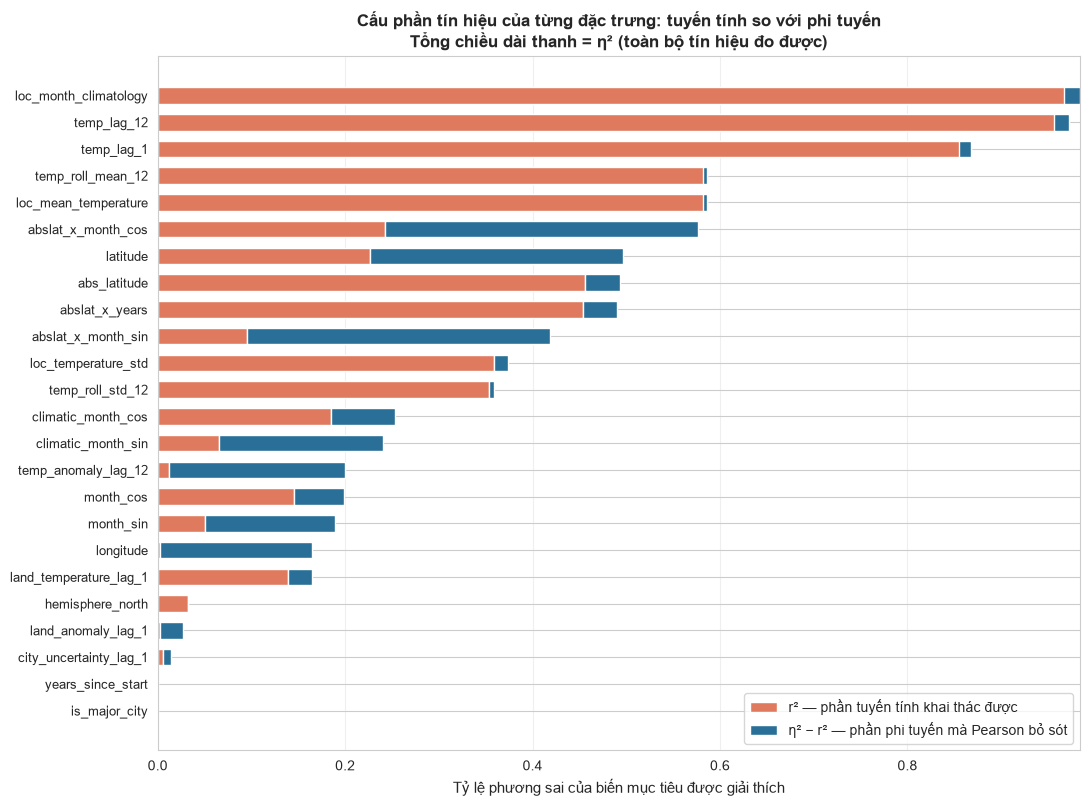

Năm đặc trưng có phần phi tuyến lớn nhất (mô hình tuyến tính khai thác được ít nhất):


,Nhóm,Pearson r,r2,eta2,Phi tuyến (eta2 - r2)
Feature,,,,,
abslat_x_month_cos,Tương tác,-0.4919,0.2420,0.5762,0.3342
abslat_x_month_sin,Tương tác,-0.3085,0.0952,0.4191,0.3239
latitude,Địa lý,-0.4761,0.2266,0.4965,0.2698
temp_anomaly_lag_12,Trễ / Trượt,-0.1092,0.0119,0.2001,0.1882
climatic_month_sin,Thời gian,-0.2567,0.0659,0.2402,0.1744


In [22]:
plot_metrics = feature_metrics.dropna(subset=['eta2']).sort_values('eta2')

fig, ax = plt.subplots(figsize=(11, max(6, len(plot_metrics) * 0.34)))
y_positions = np.arange(len(plot_metrics))

# r² là phần mô hình tuyến tính khai thác được; phần còn lại tới η² là phi tuyến.
ax.barh(y_positions, plot_metrics['r2'], height=0.62,
        color='#e07a5f', label='r² — phần tuyến tính khai thác được')
ax.barh(y_positions, plot_metrics['eta2'] - plot_metrics['r2'], height=0.62,
        left=plot_metrics['r2'], color='#2a6f97',
        label='η² − r² — phần phi tuyến mà Pearson bỏ sót')

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_metrics.index, fontsize=9)
ax.set_xlabel('Tỷ lệ phương sai của biến mục tiêu được giải thích', fontsize=11)
ax.set_title('Cấu phần tín hiệu của từng đặc trưng: tuyến tính so với phi tuyến\n'
             'Tổng chiều dài thanh = η² (toàn bộ tín hiệu đo được)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '08_feature_signal_comparison.png', dpi=200,
            bbox_inches='tight')
print('Đã lưu: reports/images/08_feature_signal_comparison.png')
plt.show()

print('Năm đặc trưng có phần phi tuyến lớn nhất '
      '(mô hình tuyến tính khai thác được ít nhất):')
display(
    feature_metrics.nlargest(5, 'Phi tuyến (eta2 - r2)')[
        ['Nhóm', 'Pearson r', 'r2', 'eta2', 'Phi tuyến (eta2 - r2)']
    ]
)

Mỗi thanh trên biểu đồ được chia thành hai phần: phần cam là `r²` — lượng tín hiệu mà một mô hình tuyến tính khai thác được; phần xanh là `η² − r²` — lượng tín hiệu chỉ mô hình phi tuyến mới lấy được.

Đây là kết luận có ý nghĩa trực tiếp cho Notebook 06: nếu phần xanh chiếm tỷ trọng lớn ở nhiều đặc trưng quan trọng, thì hồi quy tuyến tính (Linear Regression, Ridge, Lasso) sẽ **thua rõ rệt** so với các mô hình dạng cây (Decision Tree, Random Forest, Gradient Boosting) — và đó là điều cần được kiểm chứng bằng số liệu ở Notebook 06 thay vì phỏng đoán trước.

### 6.3. Feature Importance

Tương quan chỉ đo liên hệ của **từng** đặc trưng với target một cách riêng lẻ. Feature importance đo mức đóng góp của đặc trưng khi **các đặc trưng khác cùng có mặt**, nên phát hiện được trường hợp một đặc trưng mạnh nhưng chỉ lặp lại thông tin của đặc trưng khác.

Notebook dùng Random Forest trên một mẫu nhỏ. `scikit-learn` là phụ thuộc tùy chọn: nếu chưa cài, cell in hướng dẫn cài đặt và bỏ qua, phần đánh giá vẫn đầy đủ nhờ η² ở Mục 6.2 — notebook không bị dừng giữa dòng.

Huấn luyện Random Forest trên 120,000 dòng đầy đủ giá trị (32.1% mẫu đánh giá)...
R² trên chính tập vừa huấn luyện: 0.9930  (chỉ để tham khảo, không phải chỉ số đánh giá mô hình)


,importance
loc_month_climatology,0.9927
years_since_start,0.0015
land_anomaly_lag_1,0.0007
temp_lag_1,0.0006
land_temperature_lag_1,0.0006
abslat_x_month_sin,0.0005
temp_roll_mean_12,0.0004
temp_anomaly_lag_12,0.0004
temp_lag_12,0.0004
abslat_x_years,0.0004


Đã lưu: reports/images/09_feature_importance.png


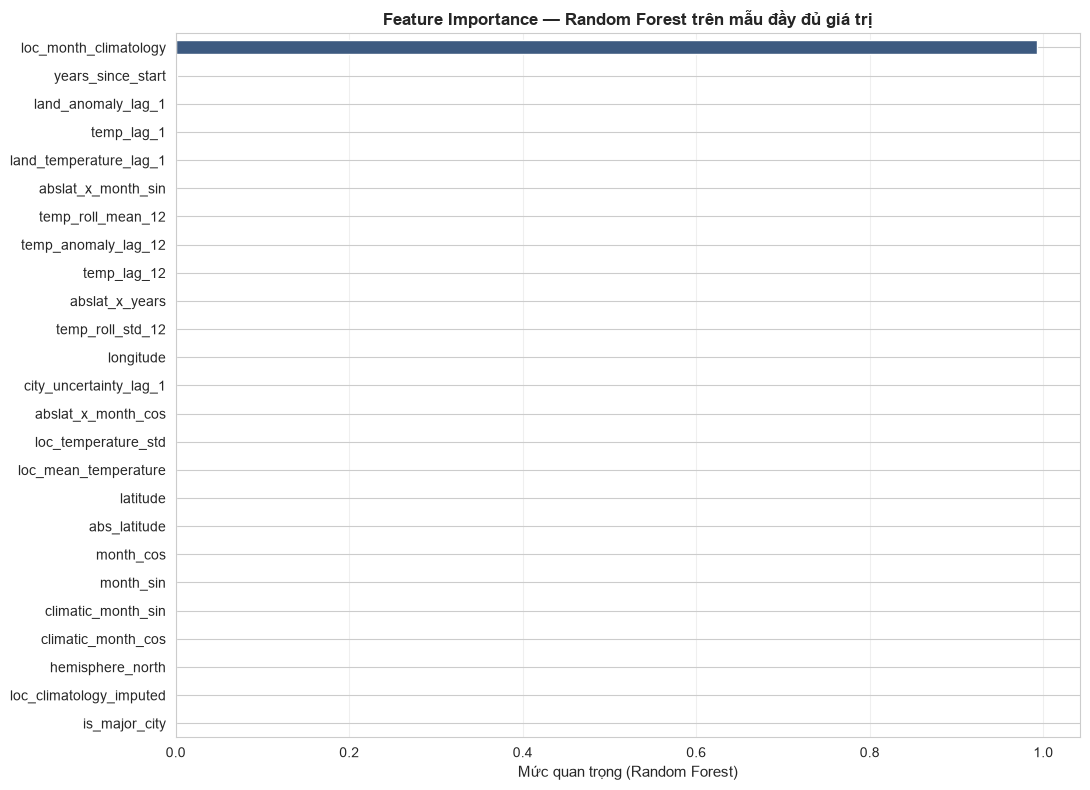

In [23]:
IMPORTANCE_SAMPLE_ROWS = 120_000
feature_importance = None

try:
    from sklearn.ensemble import RandomForestRegressor
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False

if not HAS_SKLEARN:
    print('scikit-learn chưa được cài nên bỏ qua Feature Importance.')
    print('Cài đặt bằng:  python -m pip install scikit-learn')
    print('Phần đánh giá vẫn đầy đủ nhờ η² ở Mục 6.2.')
else:
    # Random Forest không nhận NaN, nên chỉ dùng các dòng có đủ mọi đặc trưng.
    dense_df = eval_df[CANDIDATE_FEATURES + [TARGET_COLUMN]].dropna()
    if len(dense_df) > IMPORTANCE_SAMPLE_ROWS:
        dense_df = dense_df.sample(n=IMPORTANCE_SAMPLE_ROWS, random_state=RANDOM_SEED)

    print(f'Huấn luyện Random Forest trên {len(dense_df):,} dòng đầy đủ giá trị '
          f'({len(dense_df) / len(eval_df):.1%} mẫu đánh giá)...')
    forest = RandomForestRegressor(
        n_estimators=60,
        max_depth=14,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=RANDOM_SEED,
    )
    forest.fit(dense_df[CANDIDATE_FEATURES], dense_df[TARGET_COLUMN])

    feature_importance = (
        pd.Series(forest.feature_importances_, index=CANDIDATE_FEATURES, name='importance')
        .sort_values(ascending=False)
    )
    print(f'R² trên chính tập vừa huấn luyện: {forest.score(dense_df[CANDIDATE_FEATURES], dense_df[TARGET_COLUMN]):.4f}'
          '  (chỉ để tham khảo, không phải chỉ số đánh giá mô hình)')
    display(feature_importance.to_frame())

    fig, ax = plt.subplots(figsize=(11, max(6, len(feature_importance) * 0.32)))
    feature_importance.sort_values().plot.barh(ax=ax, color='#3d5a80')
    ax.set_xlabel('Mức quan trọng (Random Forest)', fontsize=11)
    ax.set_title('Feature Importance — Random Forest trên mẫu đầy đủ giá trị',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(REPORT_IMAGES_DIR / '09_feature_importance.png', dpi=200, bbox_inches='tight')
    print('Đã lưu: reports/images/09_feature_importance.png')
    plt.show()

Nếu cell chạy được, cần lưu ý hai điều khi đọc kết quả. Thứ nhất, `R²` in ra được tính trên chính tập vừa huấn luyện nên luôn lạc quan; đây **không** phải chỉ số đánh giá mô hình — việc đó thuộc Notebook 06 với tập test tách theo thời gian. Thứ hai, importance của Random Forest bị chia đều giữa các đặc trưng trùng lặp thông tin, nên một đặc trưng có importance thấp chưa hẳn vô dụng; cần đọc cùng bảng đa cộng tuyến ở Mục 6.4.

Việc phải bỏ các dòng thiếu giá trị cũng khiến tập này nghiêng về giai đoạn sau của dữ liệu — nơi các đặc trưng trễ đã có đủ quá khứ.

### 6.4. Kiểm tra đa cộng tuyến giữa các đặc trưng

Quá trình tạo feature có thể sinh ra các cặp gần như trùng thông tin, ví dụ climatology với lag 12 tháng hoặc các thống kê vị trí với rolling statistics. Cell dưới đo tương quan giữa các candidate feature trên validation và chuyển các cặp vượt ngưỡng sang quy tắc lược bỏ ở Mục 7.


In [24]:
correlation_matrix = eval_df[CANDIDATE_FEATURES].corr()

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
redundant_pairs = (
    upper_triangle.stack()
    .rename('Pearson r')
    .reset_index()
    .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B'})
)
redundant_pairs['|r|'] = redundant_pairs['Pearson r'].abs()
redundant_pairs = (
    redundant_pairs[redundant_pairs['|r|'] > REDUNDANCY_THRESHOLD]
    .sort_values('|r|', ascending=False)
    .reset_index(drop=True)
)

print(f'Ngưỡng trùng lặp: |r| > {REDUNDANCY_THRESHOLD}')
if redundant_pairs.empty:
    print('Không có cặp đặc trưng nào vượt ngưỡng trùng lặp.')
else:
    print(f'Có {len(redundant_pairs)} cặp vượt ngưỡng:')
    display(redundant_pairs[['Feature A', 'Feature B', 'Pearson r']])

Ngưỡng trùng lặp: |r| > 0.95
Có 4 cặp vượt ngưỡng:


,Feature A,Feature B,Pearson r
0,abs_latitude,abslat_x_years,0.9987
1,loc_mean_temperature,temp_roll_mean_12,0.9978
2,loc_month_climatology,temp_lag_12,0.9920
3,loc_temperature_std,temp_roll_std_12,0.9910


Mỗi cặp xuất hiện ở đây nghĩa là hai đặc trưng gần như mang cùng một thông tin. Giữ cả hai không làm mô hình chính xác hơn nhưng làm hệ số của mô hình tuyến tính mất ổn định và làm importance của mô hình cây bị chia nhỏ. Mục 7 sẽ giữ lại đặc trưng có `eta2` cao hơn trong mỗi cặp.

### 6.5. Kiểm tra rò rỉ dữ liệu

Mục này thực hiện ba nhóm kiểm tra:

1. Đo lại mức tương quan của các cột nhiệt độ cùng tháng bị loại.
2. Xác minh `temp_lag_12` đúng là target của cùng vị trí tại `t − 12`.
3. Xác minh candidate feature không chứa dữ liệu cùng kỳ/target-derived và mẫu chọn feature chỉ thuộc validation, không chứa test.


In [25]:
# --- Phép thử 1: mức tương quan của các cột bị loại --------------------
leakage_candidates = ['major_city_average_temperature', 'country_average_temperature']
leakage_rows = []
for column in leakage_candidates:
    valid = eval_df[column].notna() & eval_target.notna()
    leakage_rows.append(
        {
            'Cột nguồn': column,
            'Số dòng có giá trị': int(valid.sum()),
            'Tỷ lệ có giá trị': float(valid.mean()),
            'Pearson r với target': float(eval_df.loc[valid, column].corr(eval_target[valid]))
            if valid.sum() > 1 else float('nan'),
        }
    )
display(pd.DataFrame(leakage_rows).set_index('Cột nguồn'))
print('→ Cả hai cột đều là phép đo nhiệt độ CÙNG THÁNG và đã bao gồm chính thành phố '
      'đang dự báo, nên không được dùng làm đặc trưng.')

,Số dòng có giá trị,Tỷ lệ có giá trị,Pearson r với target
Cột nguồn,,,
major_city_average_temperature,10200,0.0273,1.0000
country_average_temperature,374280,1.0000,0.8983


→ Cả hai cột đều là phép đo nhiệt độ CÙNG THÁNG và đã bao gồm chính thành phố đang dự báo, nên không được dùng làm đặc trưng.


In [26]:
# --- Phép thử 2: temp_lag_12 phải khớp target của 12 tháng trước -------
check_frame = feature_df[['location_key', TARGET_COLUMN, 'temp_lag_12']]
verify_pool = check_frame[check_frame['temp_lag_12'].notna()]
verify_size = min(5_000, len(verify_pool))
verify_sample = verify_pool.sample(n=verify_size, random_state=RANDOM_SEED)

truth_lookup = pd.Series(
    feature_df[TARGET_COLUMN].to_numpy(), index=feature_df['location_key'].to_numpy()
)
expected_lag = truth_lookup.reindex(verify_sample['location_key'].to_numpy() - 12).to_numpy()
lag_matches = np.allclose(
    verify_sample['temp_lag_12'].to_numpy(dtype='float64'),
    expected_lag.astype('float64'),
    equal_nan=True,
)

print(f'Kiểm tra {verify_size:,} dòng ngẫu nhiên: temp_lag_12 khớp target của 12 tháng trước '
      f'→ {"PASS" if lag_matches else "FAIL"}')
if not lag_matches:
    raise RuntimeError('temp_lag_12 không khớp giá trị quá khứ; đặc trưng trễ bị sai mốc.')

# Không đặc trưng trễ nào được trùng chính target của cùng tháng.
same_month_leak = [
    name for name in ('temp_lag_1', 'temp_lag_12', 'temp_roll_mean_12')
    if np.isclose(
        feature_df[name].corr(feature_df[TARGET_COLUMN]), 1.0, atol=1e-6
    )
]
print(f'Đặc trưng trễ trùng khớp target: {same_month_leak or "không có"}')

Kiểm tra 5,000 dòng ngẫu nhiên: temp_lag_12 khớp target của 12 tháng trước → PASS
Đặc trưng trễ trùng khớp target: không có


In [27]:
# --- Phép thử 3: không feature nào trùng target hoặc dùng dữ liệu cùng kỳ ---
LEAKAGE_CORRELATION_LIMIT = 0.999
suspicious = feature_metrics[feature_metrics['|Pearson|'] > LEAKAGE_CORRELATION_LIMIT]
if not suspicious.empty:
    display(suspicious)
    raise RuntimeError('Có feature gần như trùng khớp hoàn toàn với target.')

forbidden_same_month_features = {
    'major_city_average_temperature',
    'country_average_temperature',
    'land_average_temperature',
    'city_average_temperature_uncertainty',
    'temp_anomaly_vs_climatology',
}
forbidden_candidates = forbidden_same_month_features.intersection(CANDIDATE_FEATURES)
if forbidden_candidates:
    raise RuntimeError(
        f'Candidate feature chứa dữ liệu cùng kỳ/target-derived: {forbidden_candidates}'
    )

if not eval_df['year'].between(VALIDATION_START_YEAR, TRAIN_CUTOFF_YEAR).all():
    raise RuntimeError('Mẫu chọn feature không thuần validation theo thời gian.')
if (eval_df['year'] > TRAIN_CUTOFF_YEAR).any():
    raise RuntimeError('Dữ liệu test đã lọt vào bước chọn feature.')

print(f'PASS: không feature nào có |r| > {LEAKAGE_CORRELATION_LIMIT}.')
print('PASS: không có dữ liệu cùng kỳ hoặc feature suy ra trực tiếp từ target.')
print('PASS: đánh giá/chọn feature chỉ dùng giai đoạn validation, không dùng test.')


PASS: không feature nào có |r| > 0.999.
PASS: không có dữ liệu cùng kỳ hoặc feature suy ra trực tiếp từ target.
PASS: đánh giá/chọn feature chỉ dùng giai đoạn validation, không dùng test.


Các dòng `PASS` xác nhận những điều kiện leakage mà notebook có thể kiểm tra tự động. Chúng không thay thế việc định nghĩa đúng kịch bản dự báo; vì vậy metadata vẫn ghi rõ `forecast_scenario` và `availability` để Notebook 06/07 tuân thủ.


### 6.6. SHAP (nâng cao, tùy chọn)

SHAP phân bổ phần đóng góp của từng đặc trưng vào **từng dự báo cụ thể**, thay vì chỉ đưa ra một con số quan trọng chung cho toàn mô hình. Nhờ đó có thể trả lời những câu hỏi như: với một thành phố ở vĩ độ cao vào tháng 1, đặc trưng nào đã kéo dự báo xuống thấp.

Đây là phần nâng cao và `shap` không nằm trong `requirements.txt`, nên cell dưới chỉ chạy khi thư viện đã được cài; nếu không, notebook bỏ qua và đi tiếp.

In [28]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

if not (HAS_SHAP and HAS_SKLEARN and feature_importance is not None):
    print('Bỏ qua SHAP (cần cả shap và scikit-learn).')
    print('Nếu muốn dùng:  python -m pip install shap')
else:
    shap_sample = dense_df.sample(n=min(2_000, len(dense_df)), random_state=RANDOM_SEED)
    explainer = shap.TreeExplainer(forest)
    shap_values = explainer.shap_values(shap_sample[CANDIDATE_FEATURES], check_additivity=False)
    mean_abs_shap = (
        pd.Series(np.abs(shap_values).mean(axis=0), index=CANDIDATE_FEATURES,
                  name='mean |SHAP| (°C)')
        .sort_values(ascending=False)
    )
    display(mean_abs_shap.to_frame())
    print('Giá trị đọc là: trung bình mức dịch chuyển dự báo (°C) do đặc trưng đó gây ra.')

Bỏ qua SHAP (cần cả shap và scikit-learn).
Nếu muốn dùng:  python -m pip install shap


## 7. Lựa chọn Feature

### 7.1. Bộ quy tắc lựa chọn

Việc giữ hay loại được quyết định bằng **bộ quy tắc định lượng công khai**, áp dụng theo thứ tự, thay vì gán tay từng đặc trưng. Cách này khiến kết quả có thể tái lập và kiểm chứng được.

1. **Giữ bắt buộc.** Các đặc trưng đánh dấu `force_keep` luôn được giữ, kèm lý do ghi rõ trong bảng quyết định. Có hai trường hợp: các cặp mã hóa tuần hoàn `sin`/`cos` (chỉ có nghĩa khi đi cùng nhau, vì một mình `sin` không phân biệt được tháng 3 với tháng 9), và `years_since_start` (biến trọng tâm của bài toán biến đổi khí hậu — tín hiệu biên của nó nhỏ vì bị mùa vụ che lấp, nhưng loại nó đi thì mô hình không còn cách nào tách được xu hướng dài hạn).
2. **Loại cột hằng số.** Cột chỉ có một giá trị duy nhất không mang thông tin phân biệt và làm mọi chỉ số trở thành `NaN`.
3. **Loại nếu tín hiệu quá yếu.** Loại khi `eta2 < 0.005` **và** `|Pearson| < 0.05`. Phải thỏa mãn **cả hai** điều kiện, để không loại oan các đặc trưng phi tuyến có Pearson thấp nhưng η² cao — chính là trường hợp `latitude` ở Mục 6.2.
4. **Loại nếu trùng lặp thông tin.** Trong mỗi cặp `|r| > 0.95`, giữ đặc trưng có `eta2` cao hơn và loại đặc trưng còn lại.
5. **Giữ trong các trường hợp còn lại.**

Riêng các cột bị loại vì lý do **ngữ nghĩa** (rò rỉ, suy ra từ target, trùng lặp đã biết từ Notebook 04) không tham gia bộ quy tắc này — chúng chưa từng được đưa vào danh sách ứng viên, và được ghi lại riêng ở Mục 7.3 để bảng quyết định phản ánh đầy đủ lập luận.

In [29]:
selection_records = {
    name: {'decision': 'Giữ', 'reason': 'Đạt ngưỡng tín hiệu và không trùng lặp.'}
    for name in CANDIDATE_FEATURES
}

# --- Quy tắc 1 và 2: giữ bắt buộc, cột hằng số, tín hiệu quá yếu -------
for name in CANDIDATE_FEATURES:
    if FEATURE_CATALOG[name]['force_keep']:
        selection_records[name] = {
            'decision': 'Giữ',
            'reason': f"Giữ bắt buộc. {FEATURE_CATALOG[name]['keep_reason']}",
        }
        continue

    # Cột hằng số (hoặc toàn NaN) không có phương sai nên mọi chỉ số đều là NaN.
    if eval_df[name].nunique(dropna=True) < 2:
        selection_records[name] = {
            'decision': 'Loại',
            'reason': 'Cột hằng số trên dữ liệu hiện tại nên không mang thông tin phân biệt.',
        }
        continue

    eta = feature_metrics.loc[name, 'eta2']
    abs_pearson = feature_metrics.loc[name, '|Pearson|']
    eta_weak = not (eta == eta) or eta < MIN_ETA_SQUARED
    pearson_weak = not (abs_pearson == abs_pearson) or abs_pearson < MIN_ABS_PEARSON
    if eta_weak and pearson_weak:
        selection_records[name] = {
            'decision': 'Loại',
            'reason': f'Tín hiệu quá yếu (η²={eta:.4f} < {MIN_ETA_SQUARED}, '
                      f'|r|={abs_pearson:.4f} < {MIN_ABS_PEARSON}).',
        }

# --- Quy tắc 3: trùng lặp thông tin ------------------------------------
for _, pair in redundant_pairs.iterrows():
    first, second = pair['Feature A'], pair['Feature B']
    if selection_records[first]['decision'] == 'Loại' or selection_records[second]['decision'] == 'Loại':
        continue
    first_eta = feature_metrics.loc[first, 'eta2']
    second_eta = feature_metrics.loc[second, 'eta2']
    weaker = first if (second_eta > first_eta or not (first_eta == first_eta)) else second
    stronger = second if weaker == first else first
    if FEATURE_CATALOG[weaker]['force_keep']:
        continue
    selection_records[weaker] = {
        'decision': 'Loại',
        'reason': f'Trùng lặp thông tin với {stronger} (r={pair["Pearson r"]:.4f}); '
                  f'{stronger} có η² cao hơn.',
    }

SELECTED_FEATURES = [
    name for name in CANDIDATE_FEATURES if selection_records[name]['decision'] == 'Giữ'
]
DROPPED_FEATURES = [
    name for name in CANDIDATE_FEATURES if selection_records[name]['decision'] == 'Loại'
]

print(f'Đặc trưng ứng viên : {len(CANDIDATE_FEATURES)}')
print(f'Giữ lại            : {len(SELECTED_FEATURES)}')
print(f'Loại bỏ            : {len(DROPPED_FEATURES)}')

Đặc trưng ứng viên : 25
Giữ lại            : 19
Loại bỏ            : 6


### 7.2. Bảng quyết định giữ / loại

In [30]:
decision_table = feature_metrics.join(
    pd.DataFrame(
        [
            {
                'Feature': name,
                'Khả dụng': FEATURE_CATALOG[name]['availability'],
                'Kết quả': selection_records[name]['decision'],
                'Lý do': selection_records[name]['reason'],
            }
            for name in CANDIDATE_FEATURES
        ]
    ).set_index('Feature')
)
decision_table = decision_table[
    ['Nhóm', 'Khả dụng', 'Pearson r', 'r2', 'Spearman', 'eta2', 'Kết quả', 'Lý do']
].sort_values(['Kết quả', 'eta2'], ascending=[True, False])

display(decision_table)
display(
    decision_table.groupby(['Nhóm', 'Kết quả'], observed=True)
    .size()
    .unstack(fill_value=0)
)

,Nhóm,Khả dụng,Pearson r,r2,Spearman,eta2,Kết quả,Lý do
Feature,,,,,,,,
loc_month_climatology,Khí hậu theo vị trí,fit_stat,0.9920,0.9841,0.9934,0.9665,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
temp_lag_1,Trễ / Trượt,history,0.9317,0.8682,0.9353,0.8550,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
temp_roll_mean_12,Trễ / Trượt,history,0.7657,0.5862,0.7927,0.5820,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
abslat_x_month_cos,Tương tác,static,-0.4919,0.2420,-0.4194,0.5762,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
latitude,Địa lý,static,-0.4761,0.2266,-0.5925,0.4965,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
abs_latitude,Địa lý,static,-0.6751,0.4557,-0.7098,0.4928,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
abslat_x_month_sin,Tương tác,static,-0.3085,0.0952,-0.2838,0.4191,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
loc_temperature_std,Khí hậu theo vị trí,fit_stat,-0.5989,0.3587,-0.5792,0.3734,Giữ,Đạt ngưỡng tín hiệu và không trùng lặp.
climatic_month_cos,Thời gian,static,-0.4303,0.1851,-0.3845,0.2531,Giữ,Giữ bắt buộc. Thành phần của cặp mã hóa tuần h...


Kết quả,Giữ,Loại
Nhóm,,
Bối cảnh toàn cầu,2,0
Chất lượng dữ liệu,1,0
Khí hậu theo vị trí,2,2
Thời gian,5,0
Trễ / Trượt,3,2
Tương tác,2,1
Địa lý,4,1


Bảng này là sản phẩm chính của Mục 7: mỗi đặc trưng đều có số liệu kèm lý do giữ hoặc loại, thể hiện tư duy chọn lọc thay vì giữ lại tất cả. Bảng chéo phía dưới cho biết nhóm nào đóng góp nhiều đặc trưng hữu ích nhất và nhóm nào gần như bị loại hết — thông tin đáng đưa vào báo cáo cuối.

### 7.3. Các cột bị loại vì lý do ngữ nghĩa

Ngoài các đặc trưng bị bộ quy tắc loại, một số cột của bảng sạch bị loại vì lý do bản chất chứ không vì số liệu yếu. Nhiều cột trong đó thậm chí không được đọc vào bộ nhớ ở Mục 3.2.

In [31]:
SEMANTIC_EXCLUSIONS = [
    {
        'Cột': 'major_city_average_temperature',
        'Lý do loại': 'Rò rỉ trực tiếp: phép đo cùng tháng trùng target khi có giá trị.',
    },
    {
        'Cột': 'country_average_temperature',
        'Lý do loại': 'Nhiệt độ quốc gia cùng tháng và đã chứa thông tin thành phố cần dự báo.',
    },
    {
        'Cột': 'land_average_temperature (cùng tháng)',
        'Lý do loại': 'Không có sẵn khi dự báo tương lai; thay bằng land_temperature_lag_1.',
    },
    {
        'Cột': 'city_average_temperature_uncertainty (cùng tháng)',
        'Lý do loại': 'Chỉ xuất hiện cùng phép đo target; thay bằng city_uncertainty_lag_1.',
    },
    {
        'Cột': 'land_max/min/land_and_ocean_temperature',
        'Lý do loại': 'Đều là bối cảnh cùng tháng, không phù hợp kịch bản dự báo một bước.',
    },
    {
        'Cột': 'month / quarter / decade (dạng số nguyên thô)',
        'Lý do loại': 'Quan hệ tuần hoàn được biểu diễn bằng sin/cos và xu hướng thời gian.',
    },
    {
        'Cột': 'city_temperature_iqr_outlier',
        'Lý do loại': 'Cờ phân tích chất lượng, không phải thông tin có sẵn khi dự báo.',
    },
    {
        'Cột': 'latitude_zone / climatic_season',
        'Lý do loại': 'Chỉ dùng phân tích; thông tin đã có trong latitude và mã hóa chu kỳ.',
    },
    {
        'Cột': 'temp_anomaly_vs_climatology',
        'Lý do loại': 'Suy ra trực tiếp từ target, chỉ dùng cho insight ở Mục 8.',
    },
]
display(pd.DataFrame(SEMANTIC_EXCLUSIONS).set_index('Cột'))

print('Danh sách đặc trưng cuối cùng:')
for index, name in enumerate(SELECTED_FEATURES, start=1):
    meta = FEATURE_CATALOG[name]
    print(f'  {index:2d}. {name:30s} [{meta["group"]} · {meta["availability"]}]')


,Lý do loại
Cột,
major_city_average_temperature,Rò rỉ trực tiếp: phép đo cùng tháng trùng targ...
country_average_temperature,Nhiệt độ quốc gia cùng tháng và đã chứa thông ...
land_average_temperature (cùng tháng),Không có sẵn khi dự báo tương lai; thay bằng l...
city_average_temperature_uncertainty (cùng tháng),Chỉ xuất hiện cùng phép đo target; thay bằng c...
land_max/min/land_and_ocean_temperature,"Đều là bối cảnh cùng tháng, không phù hợp kịch..."
month / quarter / decade (dạng số nguyên thô),Quan hệ tuần hoàn được biểu diễn bằng sin/cos ...
city_temperature_iqr_outlier,"Cờ phân tích chất lượng, không phải thông tin ..."
latitude_zone / climatic_season,Chỉ dùng phân tích; thông tin đã có trong lati...
temp_anomaly_vs_climatology,"Suy ra trực tiếp từ target, chỉ dùng cho insig..."


Danh sách đặc trưng cuối cùng:
   1. month_sin                      [Thời gian · static]
   2. month_cos                      [Thời gian · static]
   3. climatic_month_sin             [Thời gian · static]
   4. climatic_month_cos             [Thời gian · static]
   5. years_since_start              [Thời gian · static]
   6. latitude                       [Địa lý · static]
   7. abs_latitude                   [Địa lý · static]
   8. hemisphere_north               [Địa lý · static]
   9. longitude                      [Địa lý · static]
  10. abslat_x_month_sin             [Tương tác · static]
  11. abslat_x_month_cos             [Tương tác · static]
  12. loc_month_climatology          [Khí hậu theo vị trí · fit_stat]
  13. loc_temperature_std            [Khí hậu theo vị trí · fit_stat]
  14. temp_lag_1                     [Trễ / Trượt · history]
  15. temp_roll_mean_12              [Trễ / Trượt · history]
  16. temp_anomaly_lag_12            [Trễ / Trượt · history]
  17. land_temperatu

Danh sách in ra chính là thứ tự đặc trưng sẽ được ghi vào `feature_metadata.json` ở Mục 9.3. Notebook 06 phải đọc đúng danh sách và đúng thứ tự này, vì mô hình sau khi huấn luyện chỉ nhận đầu vào theo một thứ tự cột cố định.

## 8. Insight mới từ tập đặc trưng

Tập đặc trưng vừa xây dựng cho phép trả lời những câu hỏi mà Notebook 04 chưa trả lời được. Mục này khai thác `temp_anomaly_vs_climatology` — phần nhiệt độ lệch khỏi mức bình thường của chính thành phố đó trong tháng đó.

Cột này **không được dùng làm đặc trưng** vì nó suy ra trực tiếp từ target. Nhưng chính vì thế nó là công cụ phân tích tốt: nó đã loại bỏ hoàn toàn ảnh hưởng của mùa vụ và của vị trí, nên phần còn lại chủ yếu là tín hiệu biến đổi khí hậu.

Đã lưu: reports/images/10_anomaly_by_latitude_zone.png


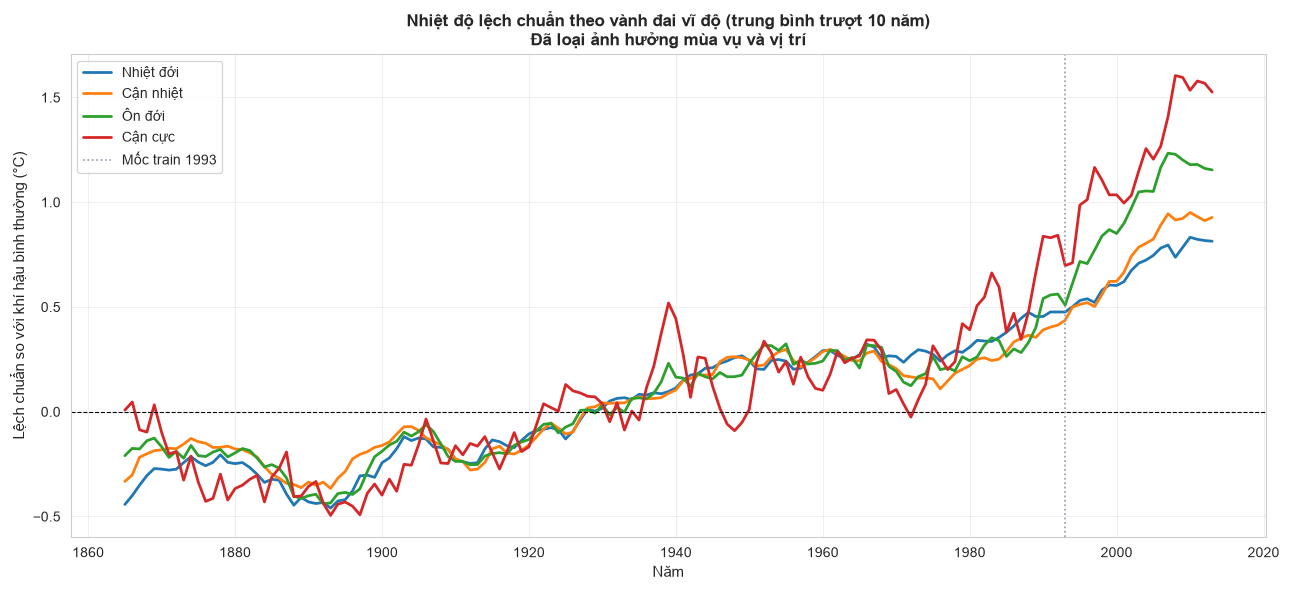

In [32]:
feature_df['temp_anomaly_vs_climatology'] = (
    feature_df[TARGET_COLUMN] - feature_df['loc_month_climatology']
).astype('float32')

anomaly_by_zone_year = (
    feature_df.groupby(['latitude_zone', 'year'], observed=True)[
        'temp_anomaly_vs_climatology'
    ]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))
for zone, zone_data in anomaly_by_zone_year.groupby('latitude_zone', observed=True):
    smoothed = zone_data.set_index('year')['temp_anomaly_vs_climatology'].rolling(
        10, min_periods=3
    ).mean()
    ax.plot(smoothed.index, smoothed.to_numpy(), linewidth=2, label=str(zone))

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(TRAIN_CUTOFF_YEAR, color='#8d99ae', linewidth=1.2, linestyle=':',
           label=f'Mốc train {TRAIN_CUTOFF_YEAR}')
ax.set_xlabel('Năm', fontsize=11)
ax.set_ylabel('Lệch chuẩn so với khí hậu bình thường (°C)', fontsize=11)
ax.set_title('Nhiệt độ lệch chuẩn theo vành đai vĩ độ (trung bình trượt 10 năm)\n'
             'Đã loại ảnh hưởng mùa vụ và vị trí',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '10_anomaly_by_latitude_zone.png', dpi=200,
            bbox_inches='tight')
print('Đã lưu: reports/images/10_anomaly_by_latitude_zone.png')
plt.show()

In [33]:
def warming_rate(group: pd.DataFrame) -> float:
    """Độ dốc °C/năm của anomaly trung bình theo năm."""
    if len(group) < 10:
        return float('nan')
    slope, _ = np.polyfit(
        group['year'].to_numpy(dtype='float64'),
        group['temp_anomaly_vs_climatology'].to_numpy(dtype='float64'),
        1,
    )
    return float(slope)


warming_by_zone = (
    anomaly_by_zone_year.groupby('latitude_zone', observed=True)[
        ['year', 'temp_anomaly_vs_climatology']
    ]
    .apply(warming_rate)
    .sort_values(ascending=False)
    .to_frame('Tốc độ ấm lên (°C/năm)')
    .rename_axis('Vành đai vĩ độ')
)
warming_by_zone['Trên 100 năm (°C)'] = warming_by_zone['Tốc độ ấm lên (°C/năm)'] * 100
display(warming_by_zone)

overall_slope = warming_rate(
    feature_df.groupby('year', observed=True)['temp_anomaly_vs_climatology']
    .mean()
    .reset_index()
)
print(f'Tốc độ anomaly toàn tập: {overall_slope:.4f}°C/năm')
print('Notebook 04 ghi nhận mức thay đổi nhiệt độ thô xấp xỉ +0,027°C/năm; '
      'năm 2013 chỉ có dữ liệu đến tháng 9.')


,Tốc độ ấm lên (°C/năm),Trên 100 năm (°C)
Vành đai vĩ độ,,
Cận cực,0.0113,1.1256
Ôn đới,0.0091,0.9108
Nhiệt đới,0.0080,0.8038
Cận nhiệt,0.0075,0.7536


Tốc độ anomaly toàn tập: 0.0083°C/năm
Notebook 04 ghi nhận mức thay đổi nhiệt độ thô xấp xỉ +0,027°C/năm; năm 2013 chỉ có dữ liệu đến tháng 9.


Mục 8 chỉ tạo insight sau khi danh sách feature đã được chốt; `temp_anomaly_vs_climatology` không phải candidate và không xuất sang Notebook 06. Kết quả theo vĩ độ bổ sung góc nhìn về xu hướng sau khi đã điều chỉnh nền khí hậu theo vị trí. Khi diễn giải vẫn cần lưu ý năm 2013 chỉ có dữ liệu đến tháng 9.


## 9. Lưu dữ liệu mới

### 9.1. Chuẩn bị bảng đầu ra

Bảng đầu ra gồm khóa nghiệp vụ, `year`/`month`, target, feature đã chọn và nhãn `data_split`.

Không lưu feature bị loại, cột suy ra từ target, phép đo cùng tháng không có sẵn lúc dự báo hoặc khóa kỹ thuật tạm. `data_split` có ba giá trị `train`, `validation`, `test`; Notebook 06 phải dùng nhãn này thay vì chia ngẫu nhiên. `is_train_period` được giữ để tương thích và bằng 1 cho train + validation.


In [34]:
OUTPUT_KEY_COLUMNS = [
    'observation_date', 'city_name', 'country_name', 'latitude', 'longitude',
    'year', 'month',
]

feature_df['data_split'] = np.select(
    [feature_fit_mask, validation_period_mask, test_period_mask],
    ['train', 'validation', 'test'],
    default='unassigned',
)
feature_df['is_train_period'] = train_period_mask.astype('int8')

output_columns = (
    OUTPUT_KEY_COLUMNS
    + [TARGET_COLUMN]
    + [name for name in SELECTED_FEATURES if name not in OUTPUT_KEY_COLUMNS]
    + ['data_split', 'is_train_period']
)
output_df = feature_df[output_columns]

forbidden_output_columns = {
    'temp_anomaly_vs_climatology',
    'major_city_average_temperature',
    'country_average_temperature',
    'land_average_temperature',
    'city_average_temperature_uncertainty',
}
leaked = forbidden_output_columns.intersection(output_df.columns)
if leaked:
    raise RuntimeError(f'Bảng đầu ra chứa cột không hợp lệ: {sorted(leaked)}')
if (feature_df['data_split'] == 'unassigned').any():
    raise RuntimeError('Có dòng chưa được gán data_split.')

print(f'Bảng đầu ra: {len(output_df):,} dòng × {output_df.shape[1]} cột')
print(f'Bộ nhớ      : {output_df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')
display(output_df.head())
display(output_df['data_split'].value_counts().to_frame('Số dòng'))
print('PASS: bảng đầu ra không chứa dữ liệu cùng kỳ hoặc feature suy ra từ target.')


Bảng đầu ra: 5,579,085 dòng × 27 cột
Bộ nhớ      : 700.9 MB


,observation_date,city_name,country_name,latitude,longitude,year,month,city_average_temperature,month_sin,month_cos,climatic_month_sin,climatic_month_cos,years_since_start,abs_latitude,hemisphere_north,abslat_x_month_sin,abslat_x_month_cos,loc_month_climatology,loc_temperature_std,temp_lag_1,temp_roll_mean_12,temp_anomaly_lag_12,land_temperature_lag_1,land_anomaly_lag_1,city_uncertainty_lag_1,data_split,is_train_period
0,1863-01-01,A Coruña,Spain,42.5900,-8.7300,1863,1,8.1310,0.5000,0.8660,0.5000,0.8660,0,42.5900,1,21.2950,36.8840,8.3255,3.8492,NaN,NaN,NaN,NaN,NaN,NaN,train,1
1,1863-02-01,A Coruña,Spain,42.5900,-8.7300,1863,2,8.7000,0.8660,0.5000,0.8660,0.5000,0,42.5900,1,36.8840,21.2950,8.9935,3.8496,8.1310,NaN,NaN,3.0340,0.6336,2.4300,train,1
2,1863-03-01,A Coruña,Spain,42.5900,-8.7300,1863,3,9.9850,1.0000,-0.0000,1.0000,-0.0000,0,42.5900,1,42.5900,-0.0000,10.2029,3.8505,8.7000,NaN,NaN,3.2530,0.3389,2.7820,train,1
3,1863-04-01,A Coruña,Spain,42.5900,-8.7300,1863,4,12.6010,0.8660,-0.5000,0.8660,-0.5000,0,42.5900,1,36.8840,-21.2950,11.4690,3.8514,9.9850,NaN,NaN,4.6820,-0.2995,0.7800,train,1
4,1863-05-01,A Coruña,Spain,42.5900,-8.7300,1863,5,13.2300,0.5000,-0.8660,0.5000,-0.8660,0,42.5900,1,21.2950,-36.8840,13.7391,3.8514,12.6010,NaN,NaN,7.9310,-0.2520,1.2260,train,1


,Số dòng
data_split,
train,4468327
test,736478
validation,374280


PASS: bảng đầu ra không chứa dữ liệu cùng kỳ hoặc feature suy ra từ target.


### 9.2. Kiểm tra dung lượng và ghi file

Bảng đầu ra có hơn 5,5 triệu dòng nên file kết quả rất lớn: dạng CSV thô khoảng 1,3 GB, còn nén gzip chỉ khoảng 200–300 MB. Vì `data/processed/` đã chứa vài file dung lượng lớn từ các notebook trước, notebook **ước lượng và kiểm tra dung lượng trống trước khi ghi**, thay vì để thao tác ghi làm đầy ổ đĩa rồi thất bại giữa chừng.

Mặc định `OUTPUT_COMPRESSION = 'gzip'`. `pandas.read_csv()` đọc file `.csv.gz` trong suốt nên Notebook 06 không cần xử lý gì thêm. Nếu cần file `.csv` thô, đặt `OUTPUT_COMPRESSION = None` ở Mục 2.3 — với điều kiện còn đủ chỗ trống.

In [35]:
BYTES_PER_VALUE = 9          # ước lượng độ dài trung bình một giá trị trong CSV
GZIP_RATIO = 0.22            # tỷ lệ nén thực nghiệm với dữ liệu dạng số

raw_estimate = len(output_df) * output_df.shape[1] * BYTES_PER_VALUE
estimated_bytes = raw_estimate * (GZIP_RATIO if OUTPUT_COMPRESSION == 'gzip' else 1.0)
free_bytes = shutil.disk_usage(PROCESSED_DIR).free

print(f'Ước lượng kích thước file : {estimated_bytes / 1024 ** 3:,.2f} GB '
      f'({OUTPUT_COMPRESSION or "không nén"})')
print(f'Dung lượng trống          : {free_bytes / 1024 ** 3:,.2f} GB')

if free_bytes < estimated_bytes * 1.3:
    raise RuntimeError(
        f'Không đủ dung lượng trống để ghi {OUTPUT_PATH.name} '
        f'(cần ~{estimated_bytes * 1.3 / 1024 ** 3:.2f} GB, còn {free_bytes / 1024 ** 3:.2f} GB).\n'
        'Cách xử lý: đặt OUTPUT_COMPRESSION = "gzip" ở Mục 2.3, '
        'hoặc dọn bớt file lớn trong data/processed/.'
    )
print('PASS: đủ dung lượng để ghi file.')

Ước lượng kích thước file : 0.28 GB (gzip)
Dung lượng trống          : 2.37 GB
PASS: đủ dung lượng để ghi file.


In [36]:
output_df.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding='utf-8',
    date_format='%Y-%m-%d',
    float_format='%.4f',
    compression=OUTPUT_COMPRESSION,
)

actual_size_mb = OUTPUT_PATH.stat().st_size / 1024 ** 2
print('Đã lưu:', OUTPUT_PATH)
print(f'Kích thước thực tế: {actual_size_mb:,.1f} MB')

# Đọc lại vài dòng đầu để xác nhận file hợp lệ và đúng thứ tự cột.
verify_df = pd.read_csv(OUTPUT_PATH, nrows=5)
if list(verify_df.columns) != output_columns:
    raise RuntimeError('Thứ tự cột trong file không khớp bảng đầu ra.')
print(f'PASS: đọc lại được {verify_df.shape[1]} cột đúng thứ tự.')
display(verify_df)

Đã lưu: E:\project1\Global-Surface-Temperature-Analysis\data\processed\feature_engineered_data.csv.gz
Kích thước thực tế: 189.9 MB
PASS: đọc lại được 27 cột đúng thứ tự.


,observation_date,city_name,country_name,latitude,longitude,year,month,city_average_temperature,month_sin,month_cos,climatic_month_sin,climatic_month_cos,years_since_start,abs_latitude,hemisphere_north,abslat_x_month_sin,abslat_x_month_cos,loc_month_climatology,loc_temperature_std,temp_lag_1,temp_roll_mean_12,temp_anomaly_lag_12,land_temperature_lag_1,land_anomaly_lag_1,city_uncertainty_lag_1,data_split,is_train_period
0,1863-01-01,A Coruña,Spain,42.5900,-8.7300,1863,1,8.1310,0.5000,0.8660,0.5000,0.8660,0,42.5900,1,21.2950,36.8840,8.3255,3.8492,NaN,NaN,NaN,NaN,NaN,NaN,train,1
1,1863-02-01,A Coruña,Spain,42.5900,-8.7300,1863,2,8.7000,0.8660,0.5000,0.8660,0.5000,0,42.5900,1,36.8840,21.2950,8.9935,3.8496,8.1310,NaN,NaN,3.0340,0.6336,2.4300,train,1
2,1863-03-01,A Coruña,Spain,42.5900,-8.7300,1863,3,9.9850,1.0000,-0.0000,1.0000,-0.0000,0,42.5900,1,42.5900,-0.0000,10.2029,3.8505,8.7000,NaN,NaN,3.2530,0.3389,2.7820,train,1
3,1863-04-01,A Coruña,Spain,42.5900,-8.7300,1863,4,12.6010,0.8660,-0.5000,0.8660,-0.5000,0,42.5900,1,36.8840,-21.2950,11.4690,3.8514,9.9850,NaN,NaN,4.6820,-0.2995,0.7800,train,1
4,1863-05-01,A Coruña,Spain,42.5900,-8.7300,1863,5,13.2300,0.5000,-0.8660,0.5000,-0.8660,0,42.5900,1,21.2950,-36.8840,13.7391,3.8514,12.6010,NaN,NaN,7.9310,-0.2520,1.2260,train,1


`float_format='%.4f'` giới hạn 4 chữ số thập phân: dữ liệu nguồn chỉ có 3 chữ số nên không mất thông tin, mà tránh được việc `float32` in ra hàng chục chữ số vô nghĩa và làm file phình lên.

Bước đọc lại 5 dòng đầu là phép kiểm tra rẻ nhưng hiệu quả: nó xác nhận file ghi thành công, giải nén được và giữ đúng thứ tự cột mà Notebook 06 sẽ dựa vào.

### 9.3. Lưu metadata đặc trưng

Metadata là hợp đồng dữ liệu giữa Notebook 05 và Notebook 06. Ngoài danh sách/thứ tự feature, file ghi kịch bản dự báo, ba mốc chia thời gian, số dòng từng split, điều kiện availability, bảng PostgreSQL đầu ra và cảnh báo năm 2013 chưa đủ tháng.

`feature_statistics.csv.gz` lưu climatology và thống kê theo từng vị trí–tháng để tái tạo các feature `fit_stat` khi dự báo dữ liệu mới. Các baseline fallback nhỏ hơn được ghi trực tiếp trong metadata. Notebook 06/07 không được tính lại những thống kê này từ validation hoặc test.


In [37]:
# Lưu bảng thống kê cần thiết để tái tạo feature fit_stat khi suy luận.
location_reference = (
    feature_df[
        ['location_id', 'city_name', 'country_name', 'latitude', 'longitude',
         'latitude_zone']
    ]
    .drop_duplicates('location_id')
    .copy()
)

fixed_location_stats = location_stats.copy()
fixed_location_stats['loc_mean_temperature'] = (
    fixed_location_stats['total'] / fixed_location_stats['count']
)
fixed_location_stats['loc_temperature_std'] = np.sqrt(
    np.maximum(
        (
            fixed_location_stats['total_sq']
            - fixed_location_stats['total'] ** 2 / fixed_location_stats['count']
        )
        / (fixed_location_stats['count'] - 1),
        0,
    )
)

feature_statistics = (
    loc_month_stats.assign(
        loc_month_climatology=(
            loc_month_stats['sum'] / loc_month_stats['count']
        )
    )
    .reset_index()[['location_id', 'month', 'loc_month_climatology']]
    .merge(location_reference, on='location_id', how='left', validate='many_to_one')
    .merge(
        fixed_location_stats[
            ['loc_mean_temperature', 'loc_temperature_std']
        ].reset_index(),
        on='location_id',
        how='left',
        validate='many_to_one',
    )
)
feature_statistics.to_csv(
    FEATURE_STATS_PATH,
    index=False,
    encoding='utf-8',
    float_format='%.6f',
    compression='gzip',
)

zone_fallback = (
    zone_month_stats['sum'] / zone_month_stats['count']
).to_dict()
global_fallback = (
    global_month_stats['sum'] / global_month_stats['count']
).to_dict()

feature_metadata = {
    'created_at': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'created_by': '05_feature_engineering.ipynb',
    'data_source': DATA_SOURCE,
    'forecast_scenario': 'one_month_ahead_with_observed_history',
    'fast_mode': FAST_MODE,
    'row_count': int(len(output_df)),
    'location_count': int(feature_df['location_id'].nunique()),
    'target': TARGET_COLUMN,
    'feature_fit_cutoff_year': int(FEATURE_FIT_CUTOFF_YEAR),
    'validation_start_year': int(VALIDATION_START_YEAR),
    'train_cutoff_year': int(TRAIN_CUTOFF_YEAR),
    'split_counts': {
        str(name): int(count)
        for name, count in output_df['data_split'].value_counts().items()
    },
    'observation_date_range': [
        str(feature_df['observation_date'].min().date()),
        str(feature_df['observation_date'].max().date()),
    ],
    'last_year_is_partial': True,
    'last_observation_date': '2013-09-01',
    'output_file': OUTPUT_PATH.name,
    'feature_statistics_file': FEATURE_STATS_PATH.name,
    'postgres_table': f'public.{FEATURE_TABLE}',
    'key_columns': OUTPUT_KEY_COLUMNS,
    'feature_names': SELECTED_FEATURES,
    'feature_details': {
        name: {
            'group': FEATURE_CATALOG[name]['group'],
            'availability': FEATURE_CATALOG[name]['availability'],
            'description': FEATURE_CATALOG[name]['description'],
            'pearson_r_validation': round(float(feature_metrics.loc[name, 'Pearson r']), 6),
            'eta_squared_validation': round(float(feature_metrics.loc[name, 'eta2']), 6),
        }
        for name in SELECTED_FEATURES
    },
    'dropped_features': {
        name: selection_records[name]['reason'] for name in DROPPED_FEATURES
    },
    'fallback_statistics': {
        'zone_month_climatology': {
            f'{str(zone)}|{int(month)}': round(float(value), 6)
            for (zone, month), value in zone_fallback.items()
        },
        'global_month_climatology': {
            str(int(month)): round(float(value), 6)
            for month, value in global_fallback.items()
        },
        'global_land_month_baseline': {
            str(int(month)): round(float(value), 6)
            for month, value in global_month_baseline.items()
        },
    },
    'semantic_exclusions': {
        item['Cột']: item['Lý do loại'] for item in SEMANTIC_EXCLUSIONS
    },
    'selection_rules': {
        'evaluation_split': 'validation',
        'min_eta_squared': MIN_ETA_SQUARED,
        'min_abs_pearson': MIN_ABS_PEARSON,
        'redundancy_threshold': REDUNDANCY_THRESHOLD,
    },
    'notes_for_notebook_06': [
        'Dùng data_split: train để fit, validation để chọn mô hình, test để báo cáo cuối.',
        'Không dùng test để chọn feature, điều chỉnh hyperparameter hoặc preprocessing.',
        'Feature availability=history cần dữ liệu các tháng trước của đúng địa điểm.',
        'Năm 2013 chỉ có dữ liệu đến tháng 9; cần nêu rõ khi báo cáo test.',
        'Dùng feature_names theo đúng thứ tự khi huấn luyện và dự báo.',
    ],
}

METADATA_PATH.write_text(
    json.dumps(feature_metadata, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('Đã lưu:', FEATURE_STATS_PATH)
print(f'Số dòng thống kê feature: {len(feature_statistics):,}')
print('Đã lưu:', METADATA_PATH)
print(f'Số đặc trưng ghi trong metadata: {len(feature_metadata["feature_names"])}')
print(json.dumps(
    {key: feature_metadata[key] for key in (
        'target', 'forecast_scenario', 'feature_fit_cutoff_year',
        'validation_start_year', 'train_cutoff_year', 'split_counts', 'feature_names'
    )},
    ensure_ascii=False,
    indent=2,
))


Đã lưu: E:\project1\Global-Surface-Temperature-Analysis\data\processed\feature_statistics.csv.gz
Số dòng thống kê feature: 37,428
Đã lưu: E:\project1\Global-Surface-Temperature-Analysis\data\processed\feature_metadata.json
Số đặc trưng ghi trong metadata: 19
{
  "target": "city_average_temperature",
  "forecast_scenario": "one_month_ahead_with_observed_history",
  "feature_fit_cutoff_year": 1983,
  "validation_start_year": 1984,
  "train_cutoff_year": 1993,
  "split_counts": {
    "train": 4468327,
    "test": 736478,
    "validation": 374280
  },
  "feature_names": [
    "month_sin",
    "month_cos",
    "climatic_month_sin",
    "climatic_month_cos",
    "years_since_start",
    "latitude",
    "abs_latitude",
    "hemisphere_north",
    "longitude",
    "abslat_x_month_sin",
    "abslat_x_month_cos",
    "loc_month_climatology",
    "loc_temperature_std",
    "temp_lag_1",
    "temp_roll_mean_12",
    "temp_anomaly_lag_12",
    "land_temperature_lag_1",
    "land_anomaly_lag_1",
   

### 9.4. Lưu tập mẫu cho ứng dụng

Ứng dụng Streamlit/FastAPI trong `app/` và Notebook 07 không cần đọc toàn bộ 5,5 triệu dòng. Một tập mẫu nhỏ cho phép khởi động nhanh và demo được ngay cả khi không có PostgreSQL.

Mẫu được lấy phân tầng theo vành đai vĩ độ để giữ được tính đa dạng địa lý, thay vì lấy ngẫu nhiên thuần có thể thiên lệch về các quốc gia có nhiều dòng như India hay China.

In [38]:
zone_labels = feature_df['latitude_zone']
sample_fraction = min(1.0, SAMPLE_ROWS / len(output_df))

# GroupBy.sample lấy mẫu theo từng vành đai vĩ độ với cùng tỷ lệ, nên cấu trúc
# địa lý của mẫu giống tập đầy đủ.
sample_df = (
    output_df.groupby(zone_labels, observed=True, sort=False)
    .sample(frac=sample_fraction, random_state=RANDOM_SEED)
    .sort_index()
)
sample_df.to_csv(SAMPLE_PATH, index=False, encoding='utf-8',
                 date_format='%Y-%m-%d', float_format='%.4f')

print('Đã lưu:', SAMPLE_PATH)
print(f'Kích thước: {SAMPLE_PATH.stat().st_size / 1024 ** 2:,.2f} MB · {len(sample_df):,} dòng')
display(
    sample_df.groupby(feature_df.loc[sample_df.index, 'latitude_zone'], observed=True)
    .size()
    .to_frame('Số dòng trong mẫu')
    .rename_axis('Vành đai vĩ độ')
)

Đã lưu: E:\project1\Global-Surface-Temperature-Analysis\data\sample\feature_sample.csv
Kích thước: 8.99 MB · 50,000 dòng


,Số dòng trong mẫu
Vành đai vĩ độ,
Nhiệt đới,18528
Cận nhiệt,13471
Ôn đới,16559
Cận cực,1442


### 9.5. Nạp bảng đặc trưng vào PostgreSQL


`public.city_temperature_features` là đầu ra chính và bắt buộc của Notebook 05. Cell sử dụng `COPY ... FROM STDIN` theo chunk trong một transaction, tạo index theo ngày và chạy `ANALYZE`. Nếu nạp lỗi, transaction rollback và notebook dừng; không có nhánh bỏ qua database.


In [39]:
import io

from sqlalchemy import text

def postgres_type(series: pd.Series) -> str:
    """Suy ra kiểu PostgreSQL từ dtype của pandas.

    Dùng các hàm kiểm tra kiểu của pandas thay vì so khớp tên dtype, vì
    pandas có thể biểu diễn ngày tháng bằng nhiều đơn vị khác nhau
    (`datetime64[ns]`, `datetime64[us]`, ...) tùy nguồn dữ liệu.
    """
    if pd.api.types.is_datetime64_any_dtype(series):
        return 'DATE'
    if pd.api.types.is_bool_dtype(series):
        return 'BOOLEAN'
    if pd.api.types.is_float_dtype(series):
        return 'DOUBLE PRECISION'
    if pd.api.types.is_integer_dtype(series):
        return 'INTEGER'
    return 'TEXT'

# Sinh DDL từ chính bảng đầu ra để schema không bị lệch với dữ liệu.
column_definitions = [
    f'    {column} {postgres_type(output_df[column])}'
    for column in output_df.columns
]

create_table_sql = (
    f'DROP TABLE IF EXISTS public.{FEATURE_TABLE};\n'
    f'CREATE TABLE public.{FEATURE_TABLE} (\n'
    + ',\n'.join(column_definitions)
    + f',\n    PRIMARY KEY ({", ".join(BUSINESS_KEY_COLUMNS)})\n);'
)
print(create_table_sql)

COPY_CHUNK_ROWS = 250_000
raw_connection = DB_ENGINE.raw_connection()
try:
    with raw_connection.cursor() as cursor:
        cursor.execute(create_table_sql)
        copy_sql = (
            f'COPY public.{FEATURE_TABLE} ({", ".join(output_df.columns)}) '
            "FROM STDIN WITH (FORMAT csv, HEADER false, NULL '')"
        )
        for start in range(0, len(output_df), COPY_CHUNK_ROWS):
            buffer = io.StringIO()
            output_df.iloc[start:start + COPY_CHUNK_ROWS].to_csv(
                buffer, index=False, header=False,
                date_format='%Y-%m-%d', float_format='%.4f',
            )
            buffer.seek(0)
            cursor.copy_expert(copy_sql, buffer)
            print(f'  đã nạp {min(start + COPY_CHUNK_ROWS, len(output_df)):,} '
                  f'/ {len(output_df):,} dòng')
        cursor.execute(
            f'CREATE INDEX idx_{FEATURE_TABLE}_date '
            f'ON public.{FEATURE_TABLE} (observation_date);'
        )
        cursor.execute(f'ANALYZE public.{FEATURE_TABLE};')
    raw_connection.commit()
except Exception:
    raw_connection.rollback()
    raise
finally:
    raw_connection.close()

with DB_ENGINE.connect() as connection:
    loaded = pd.read_sql_query(
        text(f'SELECT COUNT(*) AS row_count FROM public.{FEATURE_TABLE}'), connection
    )
display(loaded)
if int(loaded.loc[0, 'row_count']) != len(output_df):
    raise RuntimeError('Row count trong PostgreSQL không khớp bảng đầu ra.')
print(f'PASS: đã nạp đủ {len(output_df):,} dòng vào public.{FEATURE_TABLE}.')

DROP TABLE IF EXISTS public.city_temperature_features;
CREATE TABLE public.city_temperature_features (
    observation_date DATE,
    city_name TEXT,
    country_name TEXT,
    latitude DOUBLE PRECISION,
    longitude DOUBLE PRECISION,
    year INTEGER,
    month INTEGER,
    city_average_temperature DOUBLE PRECISION,
    month_sin DOUBLE PRECISION,
    month_cos DOUBLE PRECISION,
    climatic_month_sin DOUBLE PRECISION,
    climatic_month_cos DOUBLE PRECISION,
    years_since_start INTEGER,
    abs_latitude DOUBLE PRECISION,
    hemisphere_north INTEGER,
    abslat_x_month_sin DOUBLE PRECISION,
    abslat_x_month_cos DOUBLE PRECISION,
    loc_month_climatology DOUBLE PRECISION,
    loc_temperature_std DOUBLE PRECISION,
    temp_lag_1 DOUBLE PRECISION,
    temp_roll_mean_12 DOUBLE PRECISION,
    temp_anomaly_lag_12 DOUBLE PRECISION,
    land_temperature_lag_1 DOUBLE PRECISION,
    land_anomaly_lag_1 DOUBLE PRECISION,
    city_uncertainty_lag_1 DOUBLE PRECISION,
    data_split TEXT,
   

,row_count
0,5579085


PASS: đã nạp đủ 5,579,085 dòng vào public.city_temperature_features.


Khi cell chạy, `row_count` trong PostgreSQL phải khớp tuyệt đối với số dòng của bảng đầu ra. Toàn bộ thao tác nằm trong một transaction: nếu bất kỳ khối nào lỗi, `rollback()` bảo đảm database không bị bỏ lại ở trạng thái nạp dở dang.

## 10. Kết luận và bàn giao cho Notebook 06

In [40]:
summary = pd.DataFrame(
    {
        'Giá trị': [
            DATA_SOURCE,
            f'{len(feature_df):,}',
            f"{feature_df['location_id'].nunique():,}",
            f'{len(CANDIDATE_FEATURES)}',
            f'{len(SELECTED_FEATURES)}',
            f'{len(DROPPED_FEATURES)}',
            f'{TRAIN_CUTOFF_YEAR}',
            f'{OUTPUT_PATH.name} ({OUTPUT_PATH.stat().st_size / 1024 ** 2:,.1f} MB)',
        ]
    },
    index=[
        'Nguồn dữ liệu', 'Số dòng', 'Số vị trí',
        'Đặc trưng đã tạo', 'Đặc trưng được giữ', 'Đặc trưng bị loại',
        'Mốc train', 'File đầu ra',
    ],
)
display(summary)

,Giá trị
Nguồn dữ liệu,POSTGRESQL · public.cleaned_city_temperature
Số dòng,"5,579,085"
Số vị trí,"3,119"
Đặc trưng đã tạo,25
Đặc trưng được giữ,19
Đặc trưng bị loại,6
Mốc train,1993
File đầu ra,feature_engineered_data.csv.gz (189.9 MB)


Notebook 05 trả lời năm câu hỏi cốt lõi:

1. **Xây dựng feature nào?** Bảy nhóm feature được nối trực tiếp với kết quả EDA về mùa vụ, vĩ độ, xu hướng, lịch sử và chất lượng dữ liệu.
2. **Xây dựng như thế nào?** Feature tĩnh dùng ngày/vị trí; feature động chỉ dùng quá khứ; target statistics dùng leave-one-out ở feature-fit và thống kê cố định cho validation/test.
3. **Feature có hữu ích không?** Pearson, Spearman, η² và importance được tính chỉ trên validation.
4. **Giữ hay loại feature nào?** Mục 7 sinh bảng quyết định theo ngưỡng tín hiệu và trùng lặp; các cột cùng tháng không khả dụng được loại theo ngữ nghĩa.
5. **Dữ liệu đã sẵn sàng cho ML chưa?** Chỉ sẵn sàng sau khi các kiểm tra leakage PASS, metadata/file được ghi và bảng PostgreSQL có row count khớp tuyệt đối.

Bộ dữ liệu sau Feature Engineering sẽ được sử dụng ở Notebook 06 để huấn luyện, chọn mô hình bằng validation và báo cáo cuối cùng trên test.

**Notebook 06 phải:**

- Đọc `feature_metadata.json` và dùng `feature_names` đúng thứ tự.
- Dùng `data_split`: train để fit, validation để chọn mô hình/hyperparameter, test chỉ để báo cáo cuối.
- Không fit imputer, scaler hay encoder trên validation/test.
- Chỉ dùng feature `history` khi dữ liệu tháng trước thực sự có sẵn; nêu rõ cách xử lý `NaN` đầu chuỗi.
- Lưu các bảng thống kê `fit_stat` cùng pipeline suy luận nếu cần dự báo dữ liệu mới.


## 11. Checklist hoàn thành Notebook 05

- [x] Chỉ đọc dữ liệu sạch từ `public.cleaned_city_temperature` trong PostgreSQL.
- [x] Kiểm tra data contract, grain City–month và target đầy đủ.
- [x] Chia feature-fit, validation và test theo thời gian; test không tham gia chọn feature.
- [x] Chỉ nạp 16/32 cột cần dùng và hạ kiểu dữ liệu.
- [x] Chuyển kết quả Notebook 04 thành bảy nhóm feature phù hợp bài toán nhiệt độ.
- [x] Mã hóa mùa vụ tuần hoàn có hiệu chỉnh bán cầu.
- [x] Tạo target statistics leave-one-out ở fit và cố định cho validation/test.
- [x] Tạo lag/rolling theo đúng tháng lịch, không dùng `shift()` theo số dòng.
- [x] Thay feature cùng tháng bằng phiên bản lag khi cần.
- [x] Đánh giá feature bằng Pearson, Spearman, η² và Feature Importance trên validation.
- [x] Kiểm tra đa cộng tuyến và rò rỉ dữ liệu bằng code.
- [x] Lựa chọn feature bằng quy tắc định lượng, có lý do giữ/loại.
- [x] Lưu feature, metadata và tập mẫu bổ sung.
- [x] Nạp bắt buộc bảng `public.city_temperature_features` bằng `COPY` và kiểm tra row count.
- [x] Kết luận và bàn giao rõ data contract cho Notebook 06.
